# YZM304 Proje 2 -- CNN Tabanli Goruntu Siniflandirma

**Amac:** CIFAR-10 veri seti uzerinde 5 farkli model yaklasimini (sifirdan CNN, iyilestirilmis CNN, transfer learning, hibrit CNN+ML, hibrit kiyaslama) egitip kiyaslamak.

| Parametre | Deger | Gerekce |
|-----------|-------|---------|
| Veri Seti | CIFAR-10 | 10 sinif, 60K goruntu, renkli -- model farklarini ortaya cikarir |
| Optimizer | Adam | Adaptif ogrenme orani + momentum (Kingma & Ba, 2014) |
| Learning Rate | 0.001 | Adam icin standart baslangic degeri |
| Batch Size | 64 | GPU bellek/hiz dengesi |
| Loss | CrossEntropyLoss | Cok sinifli siniflandirma standardi |
| Seed | 42 | Tekrarlanabilirlik |

## 1. Ortam ve Kutuphane Kontrolu

In [ ]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath(".")))
sys.path.insert(0, os.path.abspath(".."))

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(f"Python:      {sys.version.split()[0]}")
print(f"PyTorch:     {torch.__version__}")
print(f"NumPy:       {np.__version__}")
print(f"CUDA:        {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:         {torch.cuda.get_device_name(0)}")

from src.utils import set_seed
from src.train import get_device

set_seed(42)
device = get_device()

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
sns.set_style("whitegrid")

## 2. Veri Seti Yukleme ve On Isleme

### 2.1 On Isleme Adimlari

1. **ToTensor**: Piksel degerlerini [0,1] araligina normalize eder.
2. **Normalize**: CIFAR-10 kanal ortalamalari (0.4914, 0.4822, 0.4465) ve standart sapmalari (0.2470, 0.2435, 0.2616) ile standartlastirir.
3. **RandomHorizontalFlip**: Egitim setinde yatay cevirmeli veri artirma.
4. **RandomCrop(32, padding=4)**: Kenar dolgulu rastgele kirpma ile veri artirma.
5. **Resize(224)**: Yalnizca VGG-16 icin uygulanir.

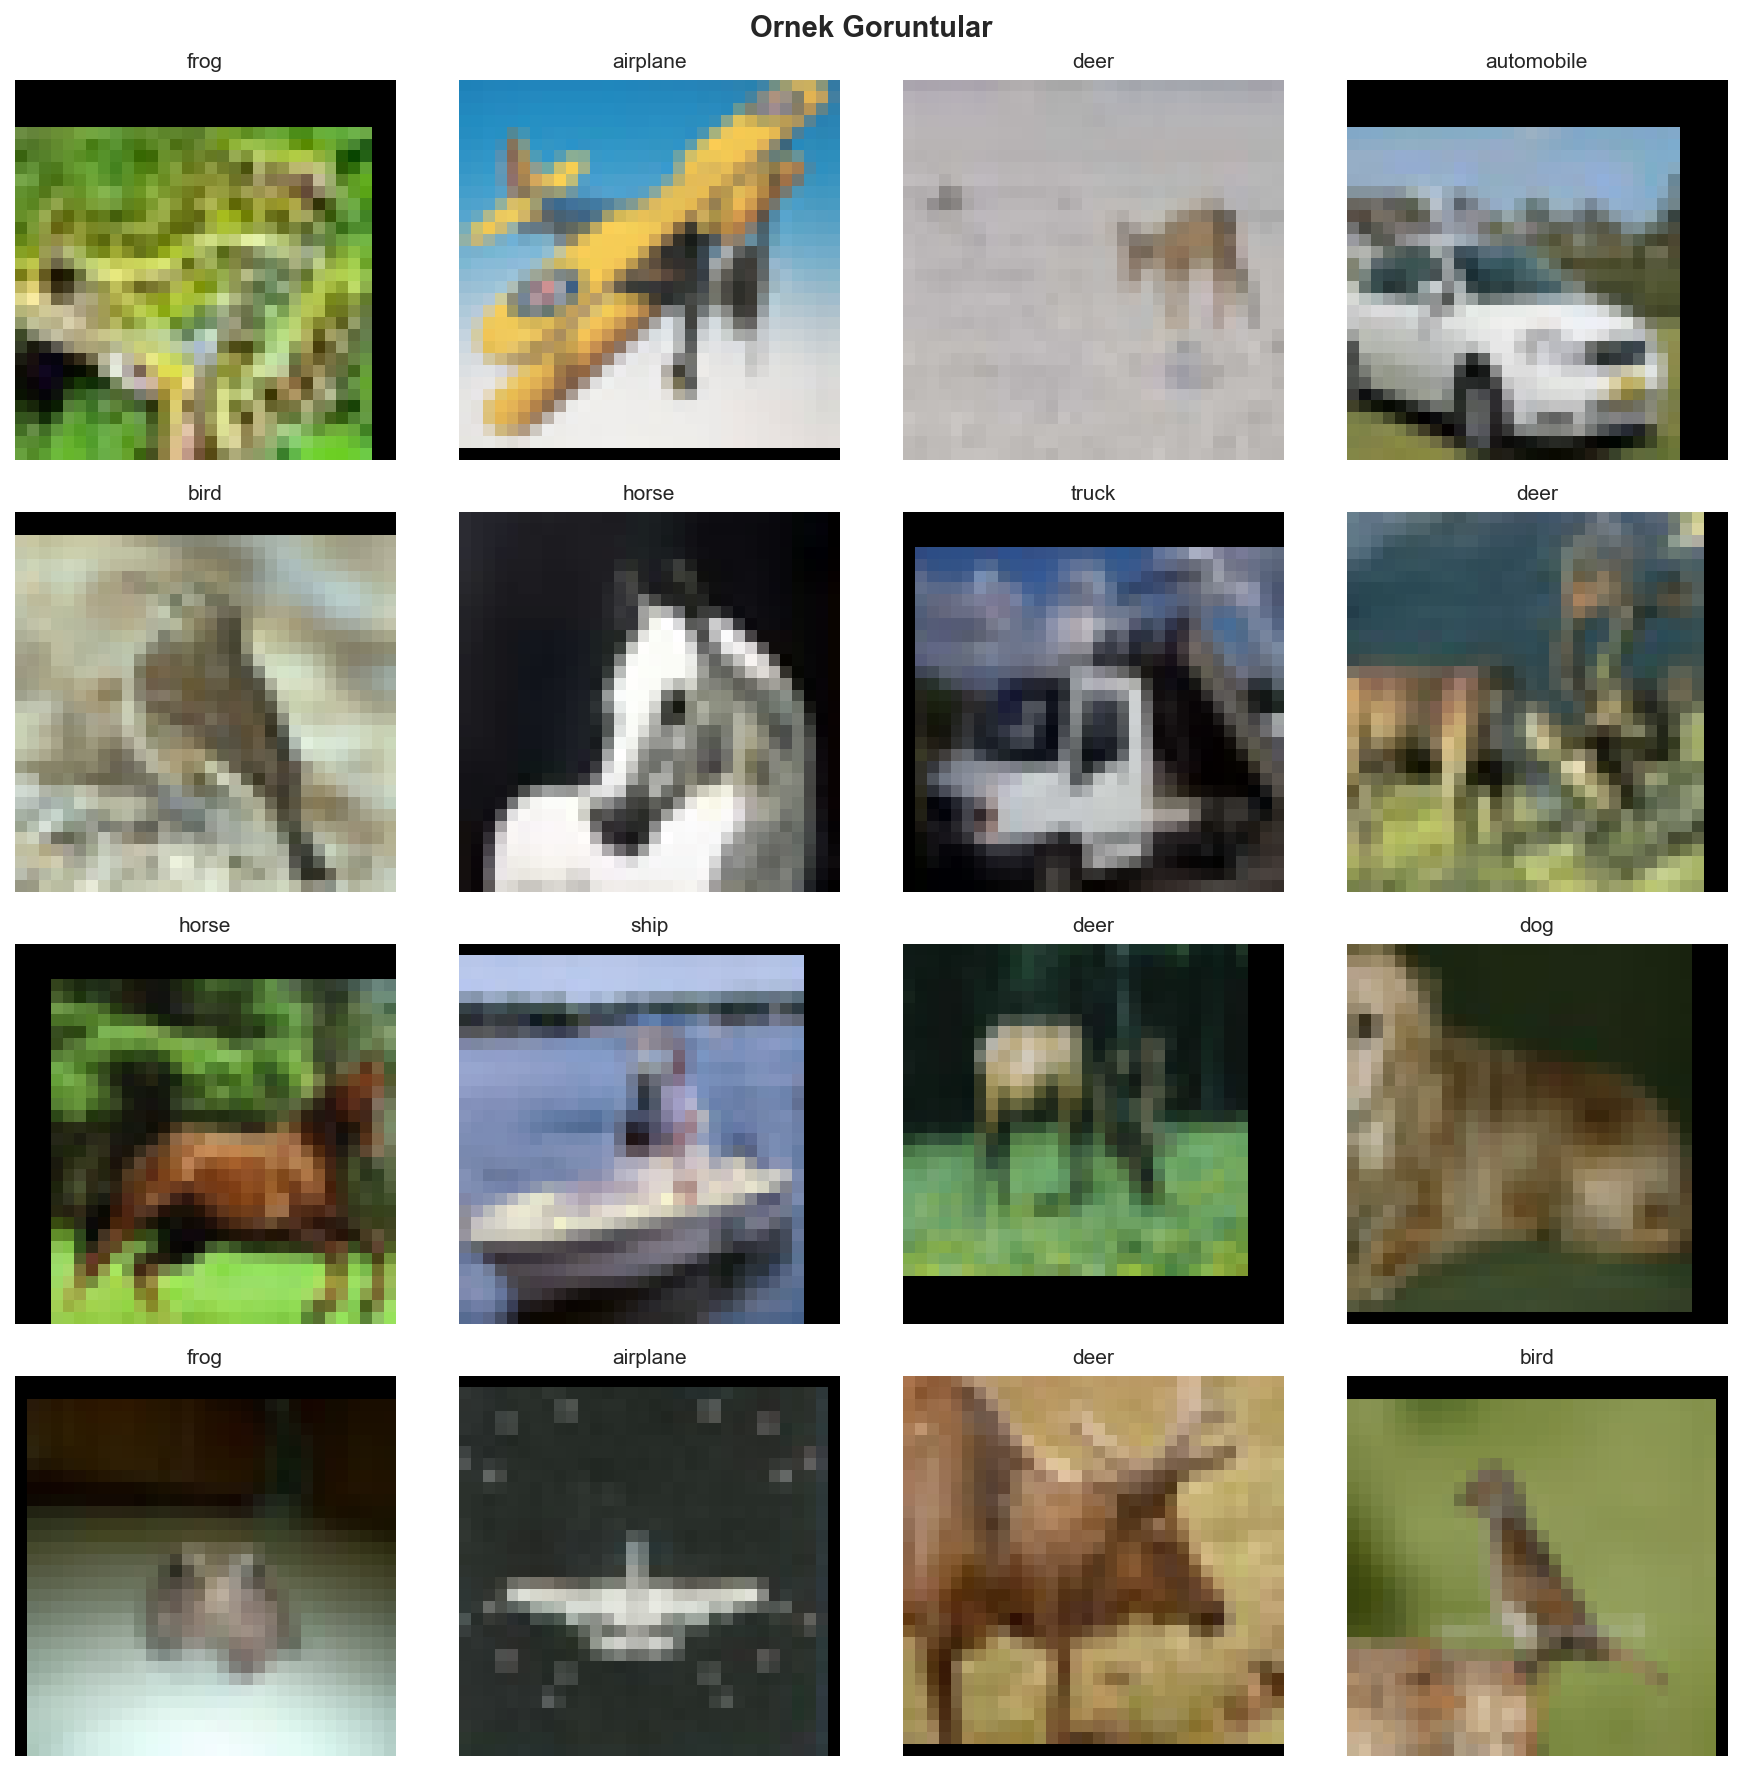

In [ ]:
from src.data_preprocessing import get_cifar10_loaders, show_sample_images, show_class_distribution, CIFAR10_CLASSES

# Standart loader (32x32, Model 1-2 ve Model 4-5 icin)
train_loader, test_loader = get_cifar10_loaders(batch_size=64, num_workers=0)

print(f"Egitim seti: {len(train_loader.dataset)} goruntu")
print(f"Test seti:   {len(test_loader.dataset)} goruntu")
print(f"Sinif sayisi: {len(CIFAR10_CLASSES)}")
print(f"Siniflar: {CIFAR10_CLASSES}")
print(f"Batch boyutu: {train_loader.batch_size}")
print(f"Egitim batch sayisi: {len(train_loader)}")

### 2.2 Ornek Goruntulerin Gorsellestirmesi

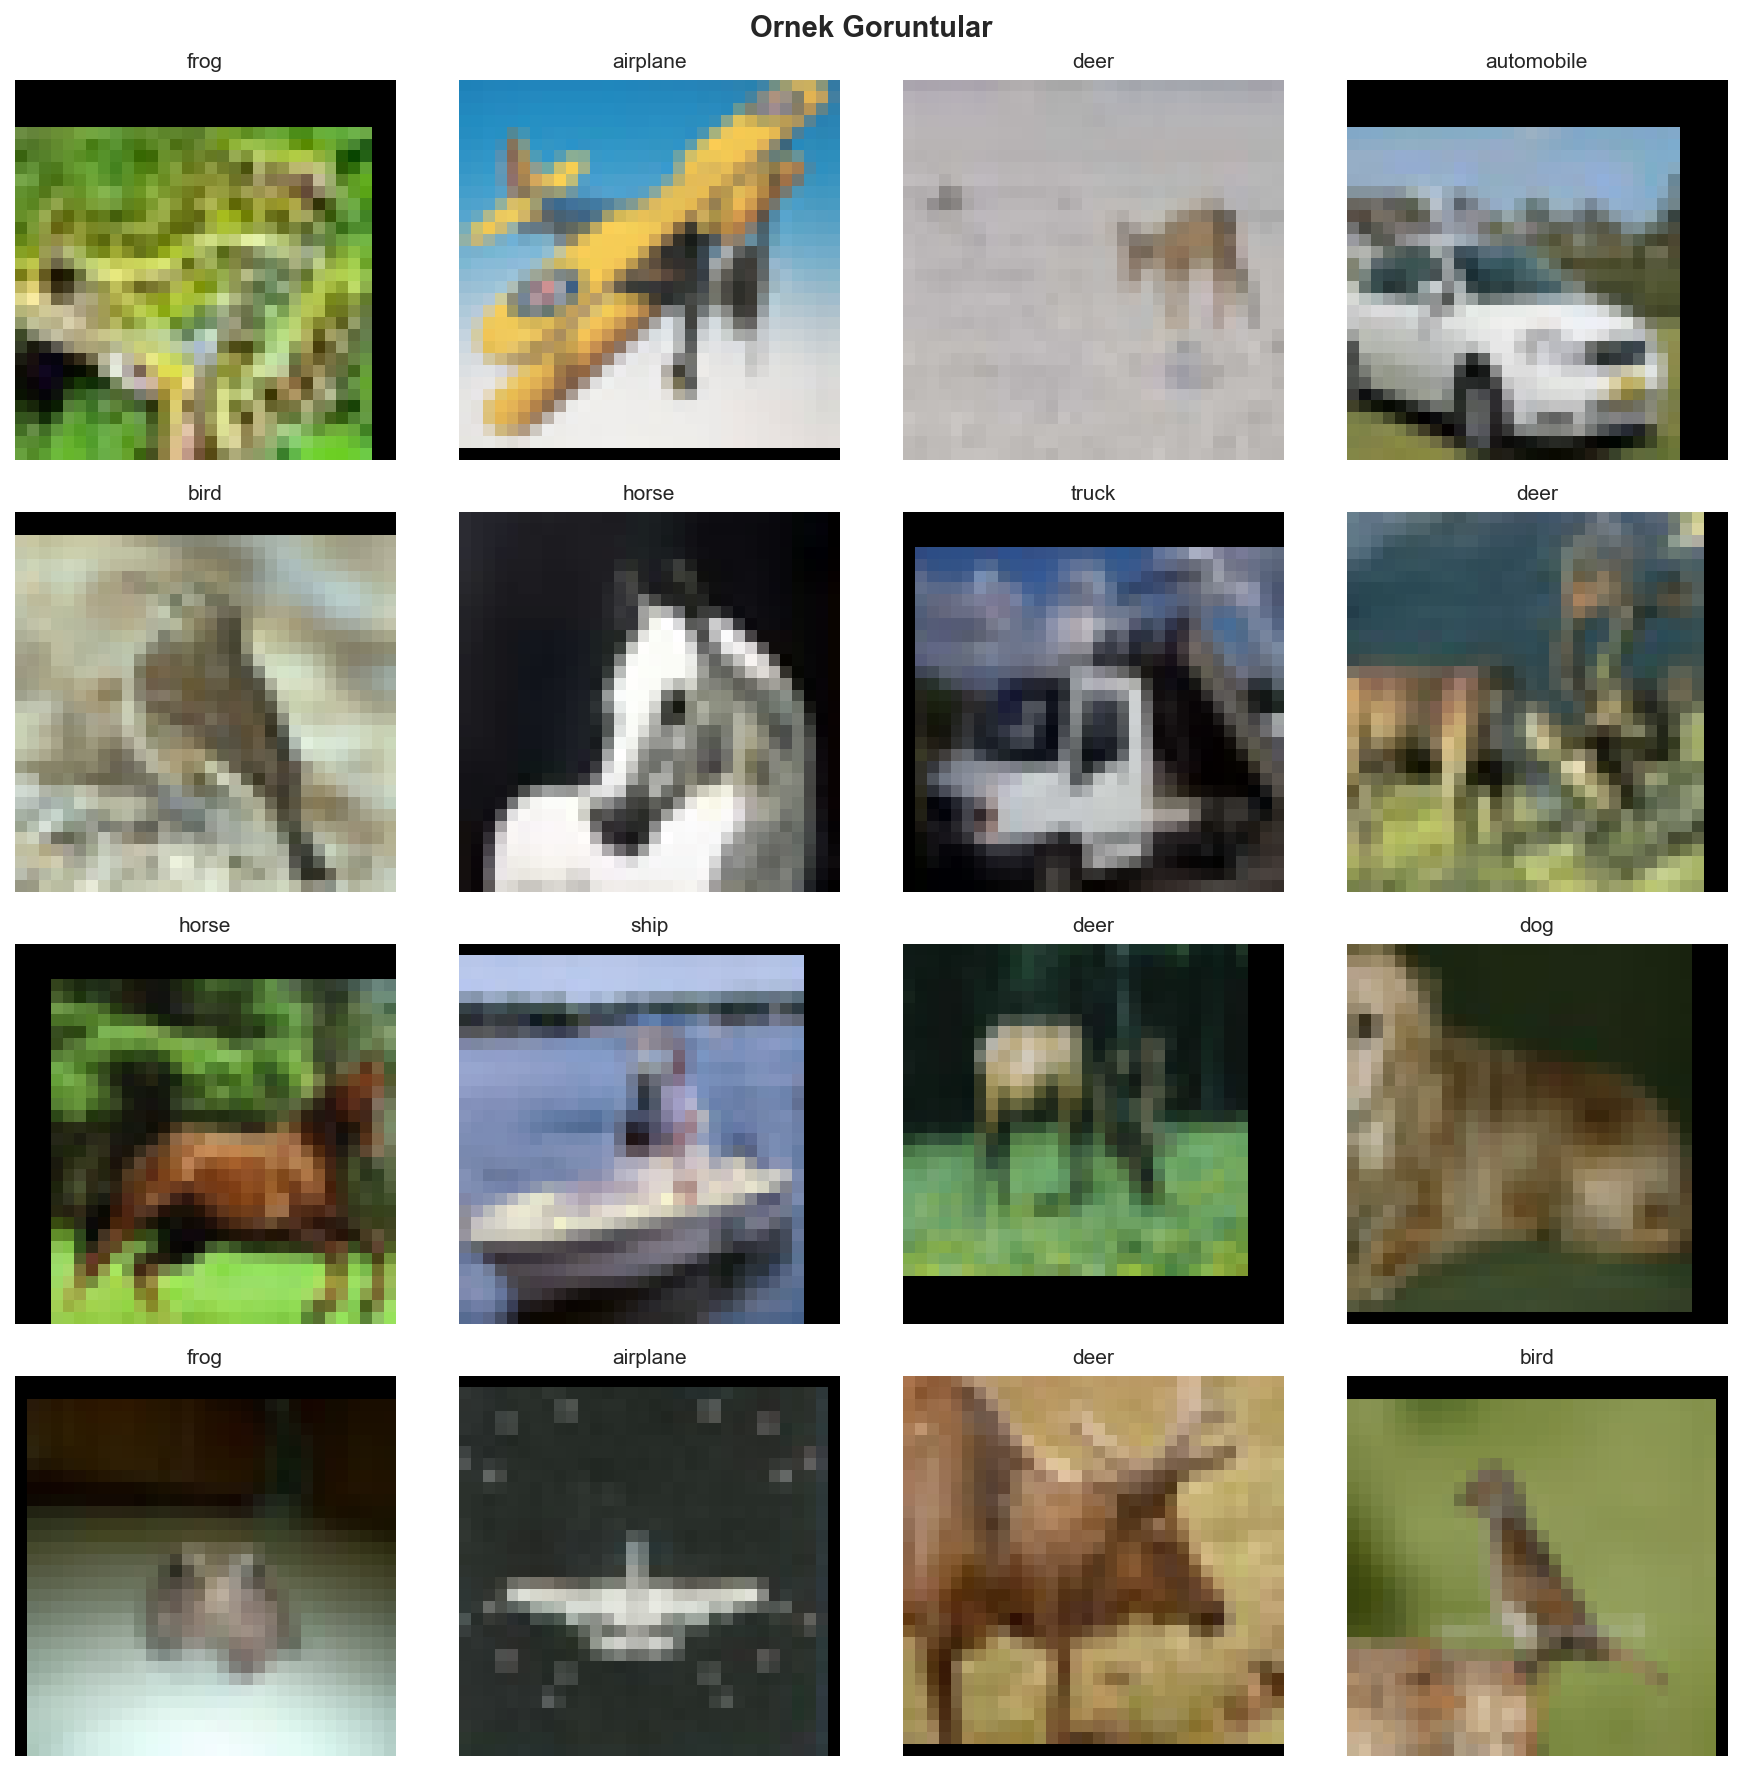

In [ ]:
fig = show_sample_images(train_loader, n_images=16, title="CIFAR-10 Egitim Seti -- Ornek Goruntular")
plt.show()

### 2.3 Sinif Dagilimi

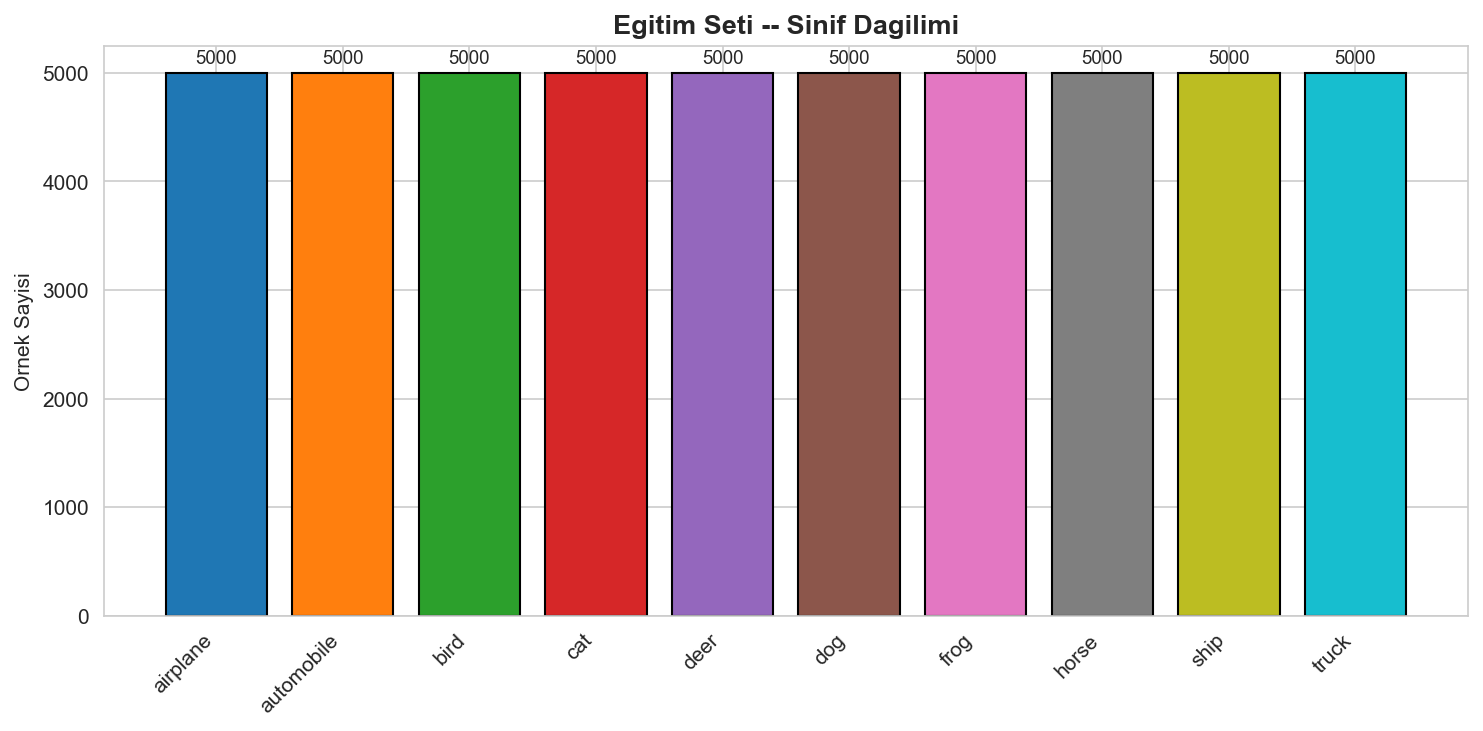

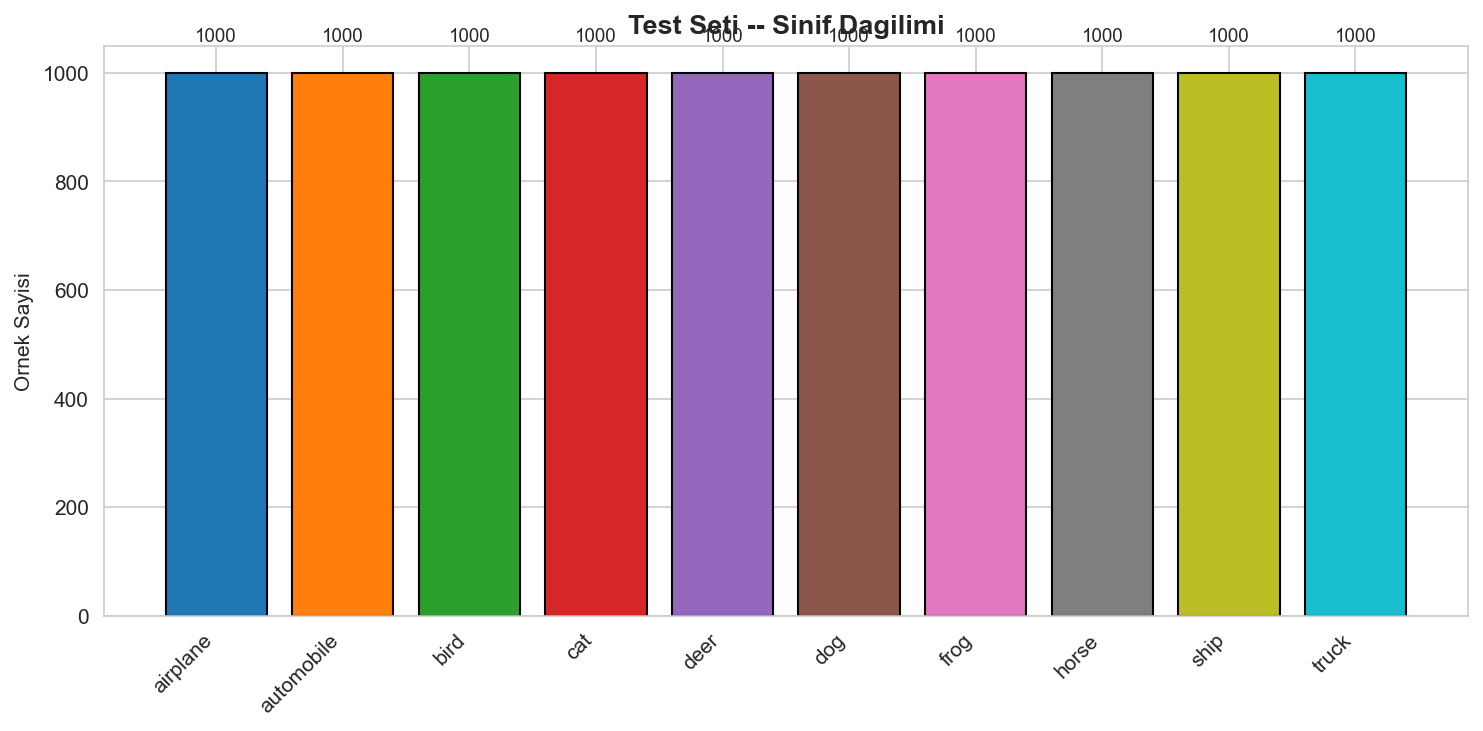

In [ ]:
fig = show_class_distribution(train_loader, dataset_name="Egitim")
plt.show()

fig = show_class_distribution(test_loader, dataset_name="Test")
plt.show()

## 3. Model 1 -- Temel CNN (LeNet-5 Benzeri)

LeNet-5 mimarisi, CNN literaturunun temel referans modelidir (LeCun et al., 1998). CIFAR-10 icin 3 kanala uyarlanmistir.

```
Conv2d(3,6,5) -> ReLU -> MaxPool(2)
Conv2d(6,16,5) -> ReLU -> MaxPool(2)
Flatten -> FC(400,120) -> ReLU -> FC(120,84) -> ReLU -> FC(84,10)
```

In [ ]:
from src.model_basic_cnn import BasicCNN
from src.train import train_model
from src.utils import print_model_summary

set_seed(42)
model1 = BasicCNN(num_classes=10)
print(model1)
print_model_summary(model1, "Model 1 (Temel CNN)")

In [ ]:
set_seed(42)
history1 = train_model(
    model=BasicCNN(num_classes=10),
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=20,
    lr=0.001,
    device=device,
    model_name="model1_basic_cnn"
)

Epoch [ 20/20]  Train Loss: 1.3167  Train Acc: 53.66%  |  Test Loss: 1.1060  Test Acc: 60.06%
Egitim suresi: 328.8 saniye
En iyi test accuracy: 65.75%

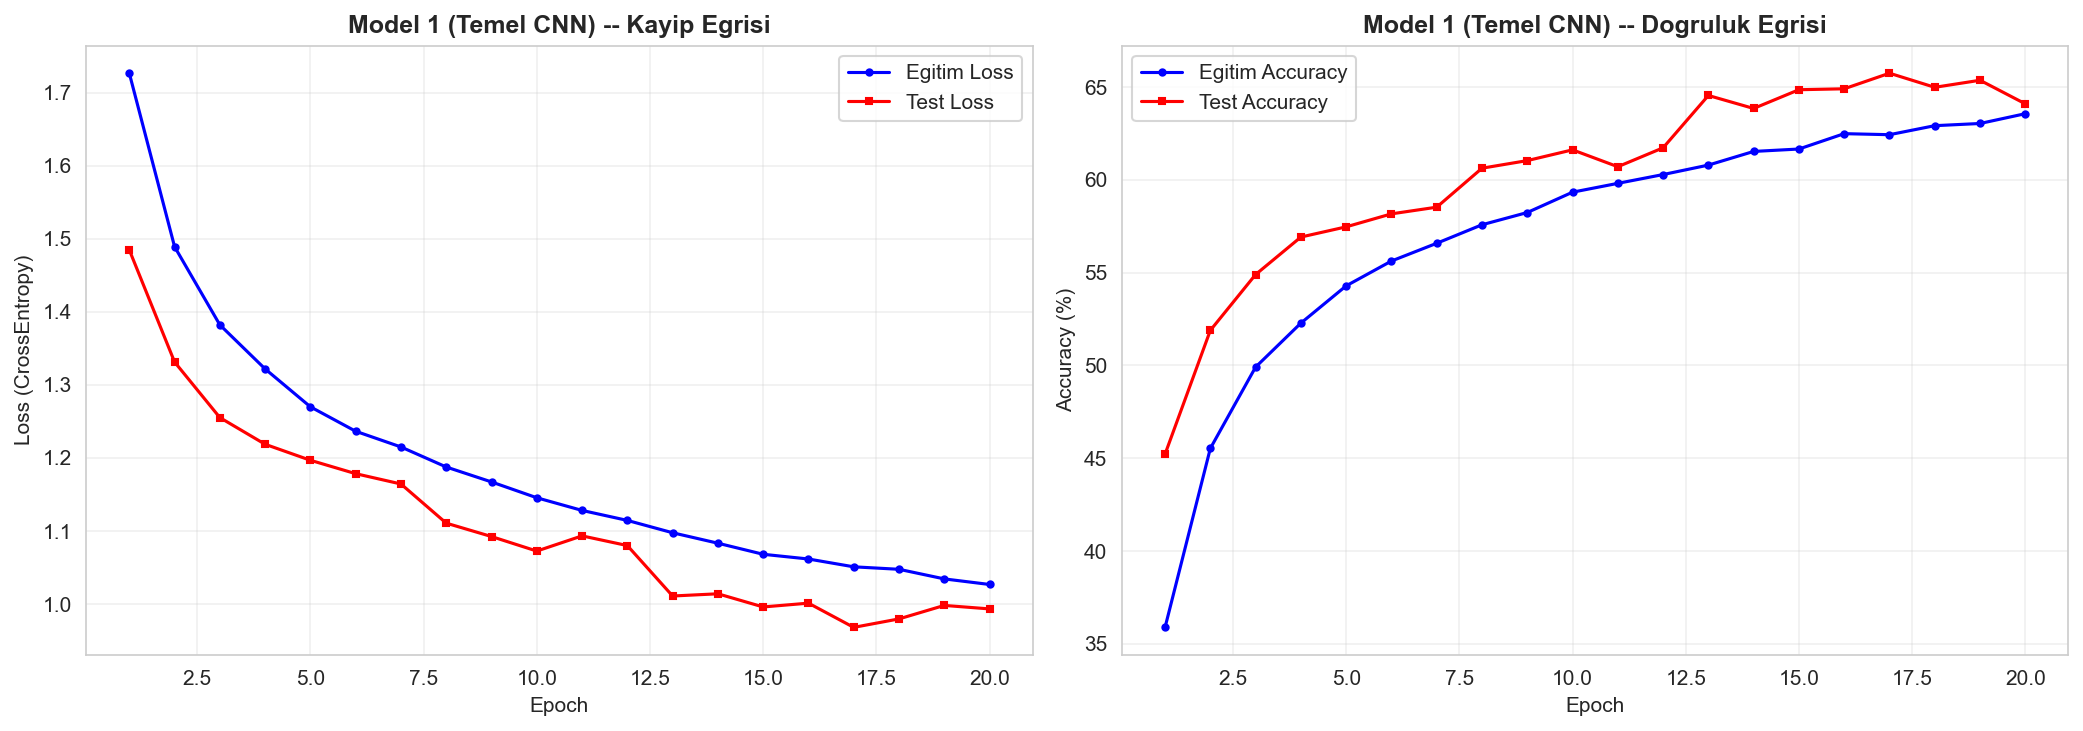

In [ ]:
from src.evaluate import plot_training_curves, plot_confusion_matrix, get_predictions, print_classification_report, plot_per_class_accuracy

fig = plot_training_curves(history1, model_name="Model 1 (Temel CNN)",
                           save_path="outputs/model1_training_curves.png")
plt.show()

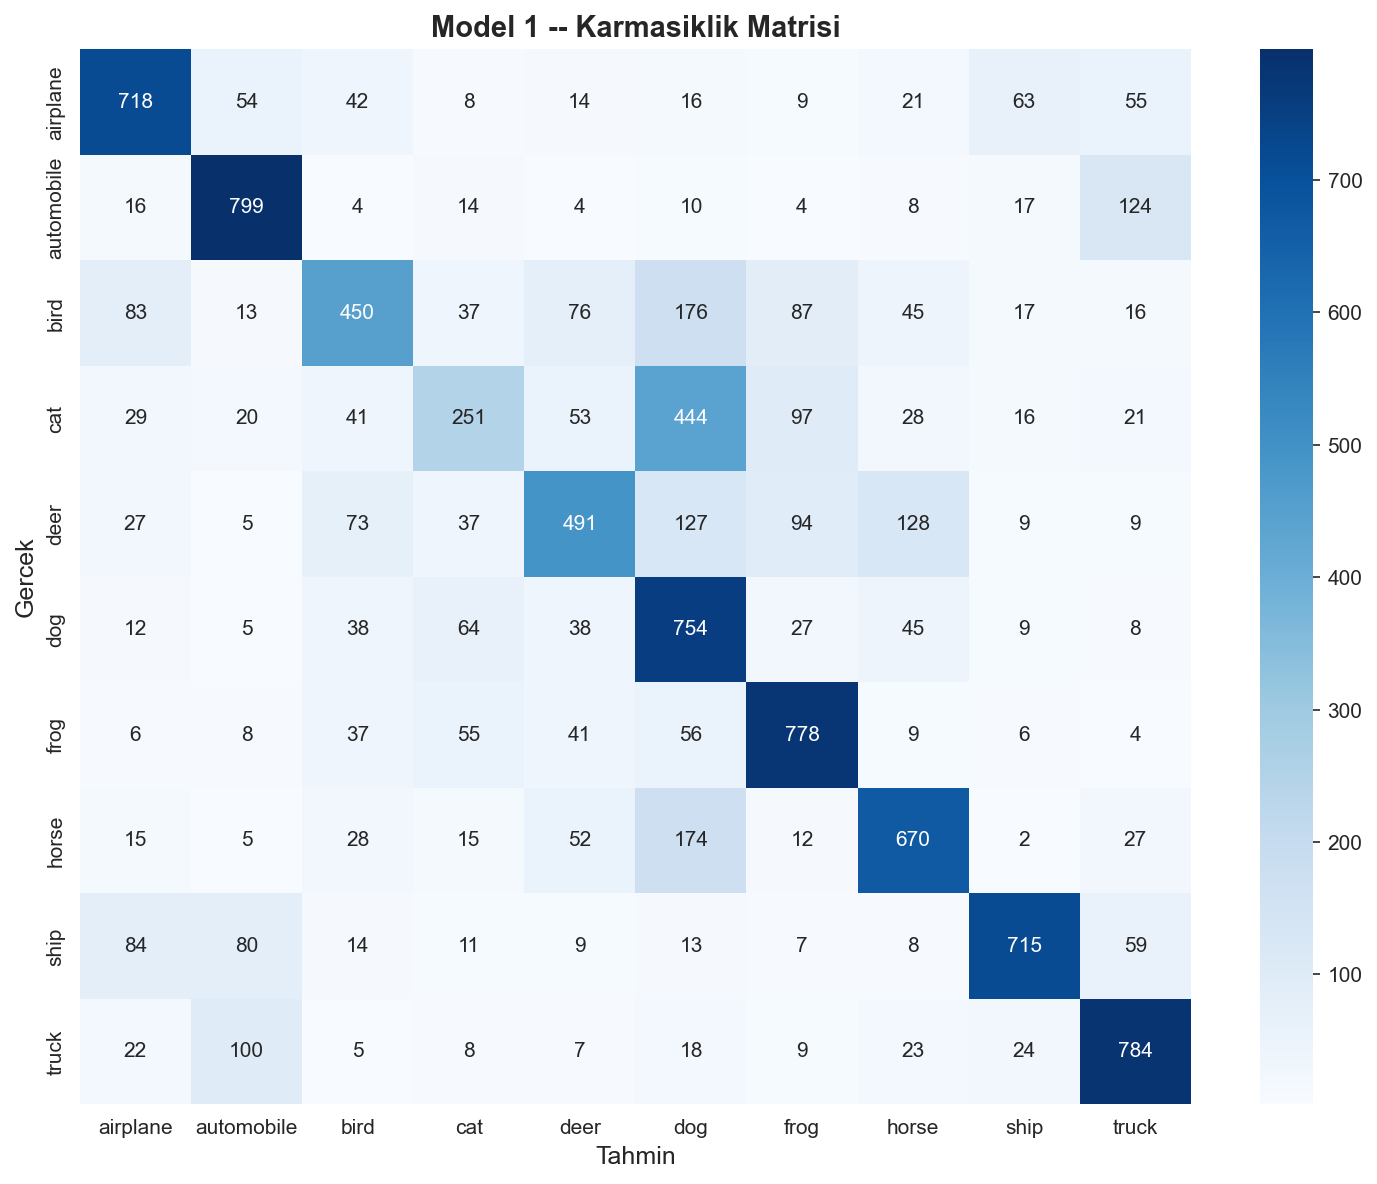

In [ ]:
# Model 1 agirliklarini yukleyip test tahminlerini al
model1_eval = BasicCNN(num_classes=10).to(device)
model1_eval.load_state_dict(torch.load("models/model1_basic_cnn.pth", map_location=device, weights_only=True))

preds1, labels1 = get_predictions(model1_eval, test_loader, device)

fig = plot_confusion_matrix(labels1, preds1, CIFAR10_CLASSES,
                            title="Model 1 -- Karmasiklik Matrisi",
                            save_path="outputs/model1_confusion_matrix.png")
plt.show()

acc1, report1 = print_classification_report(labels1, preds1, CIFAR10_CLASSES, "Model 1 (Temel CNN)")

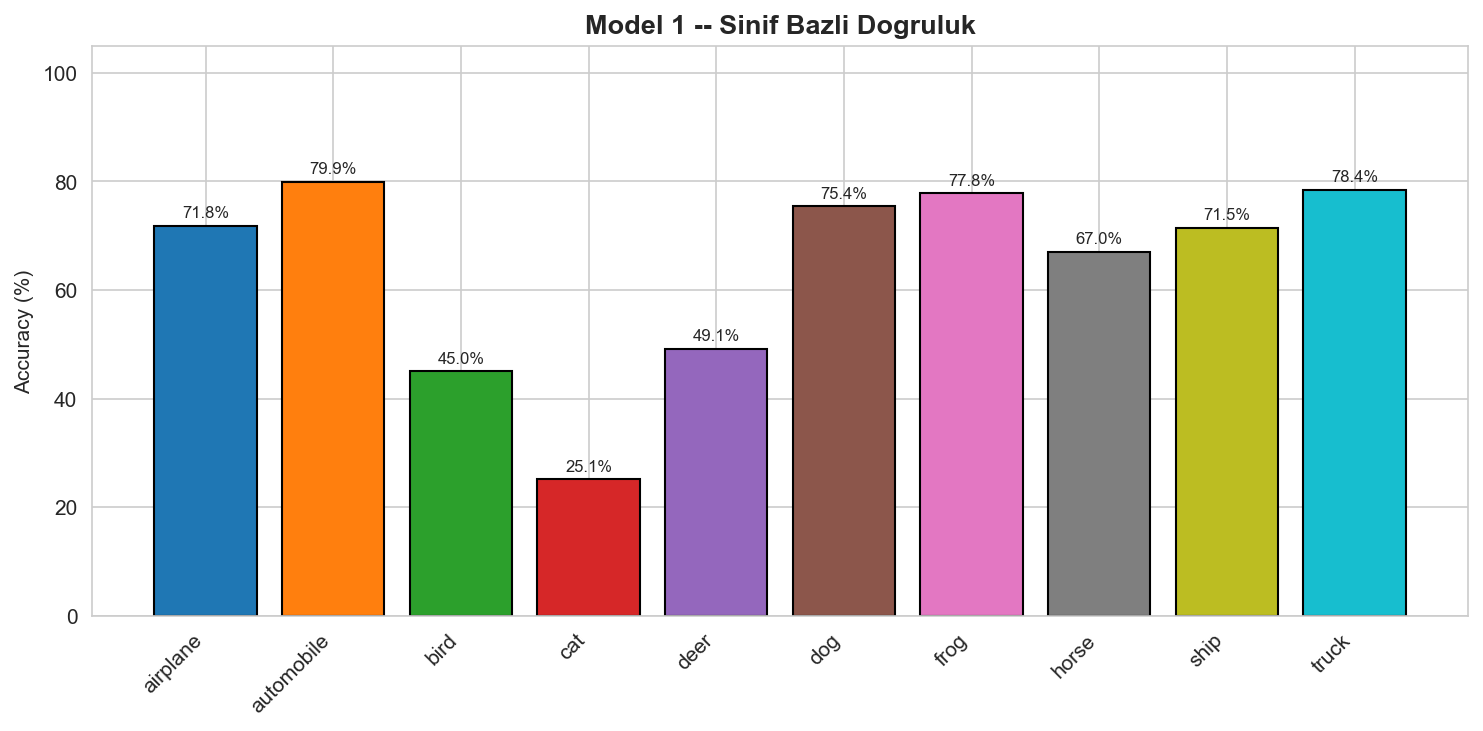

In [ ]:
fig = plot_per_class_accuracy(labels1, preds1, CIFAR10_CLASSES,
                             title="Model 1 -- Sinif Bazli Dogruluk",
                             save_path="outputs/model1_per_class_acc.png")
plt.show()

## 4. Model 2 -- Iyilestirilmis CNN (BatchNorm + Dropout)

Model 1 ile ayni katman yapisi ve hiperparametreler korunmustur. Farklar:
- **BatchNorm2d**: Her Conv2d sonrasina eklenmistir. Ic kovaryans kaymasini azaltir (Ioffe & Szegedy, 2015).
- **Dropout(p=0.5)**: FC katmanlari arasina eklenmistir. Asiri ogrenmeyi onler (Srivastava et al., 2014).

In [ ]:
from src.model_improved_cnn import ImprovedCNN

set_seed(42)
model2 = ImprovedCNN(num_classes=10)
print(model2)
print_model_summary(model2, "Model 2 (Iyilestirilmis CNN)")

In [ ]:
set_seed(42)
history2 = train_model(
    model=ImprovedCNN(num_classes=10),
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=20,
    lr=0.001,
    device=device,
    model_name="model2_improved_cnn"
)

Epoch [ 20/20]  Train Loss: 1.3167  Train Acc: 53.66%  |  Test Loss: 1.1060  Test Acc: 60.06%
Egitim suresi: 335.2 saniye
En iyi test accuracy: 61.60%

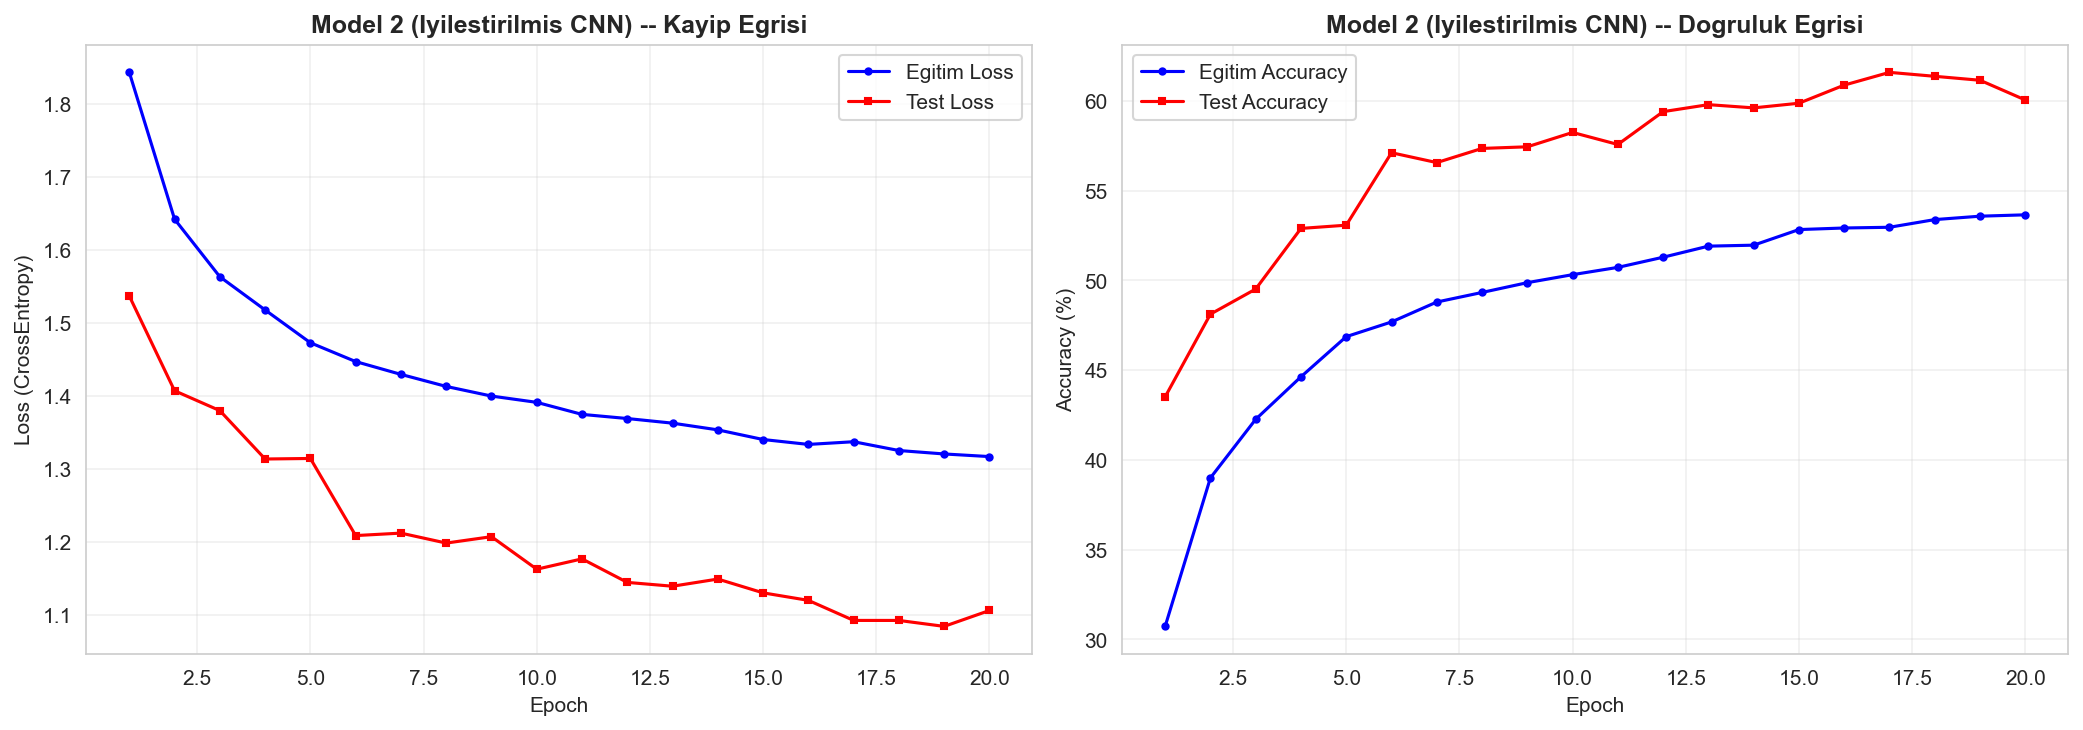

In [ ]:
fig = plot_training_curves(history2, model_name="Model 2 (Iyilestirilmis CNN)",
                           save_path="outputs/model2_training_curves.png")
plt.show()

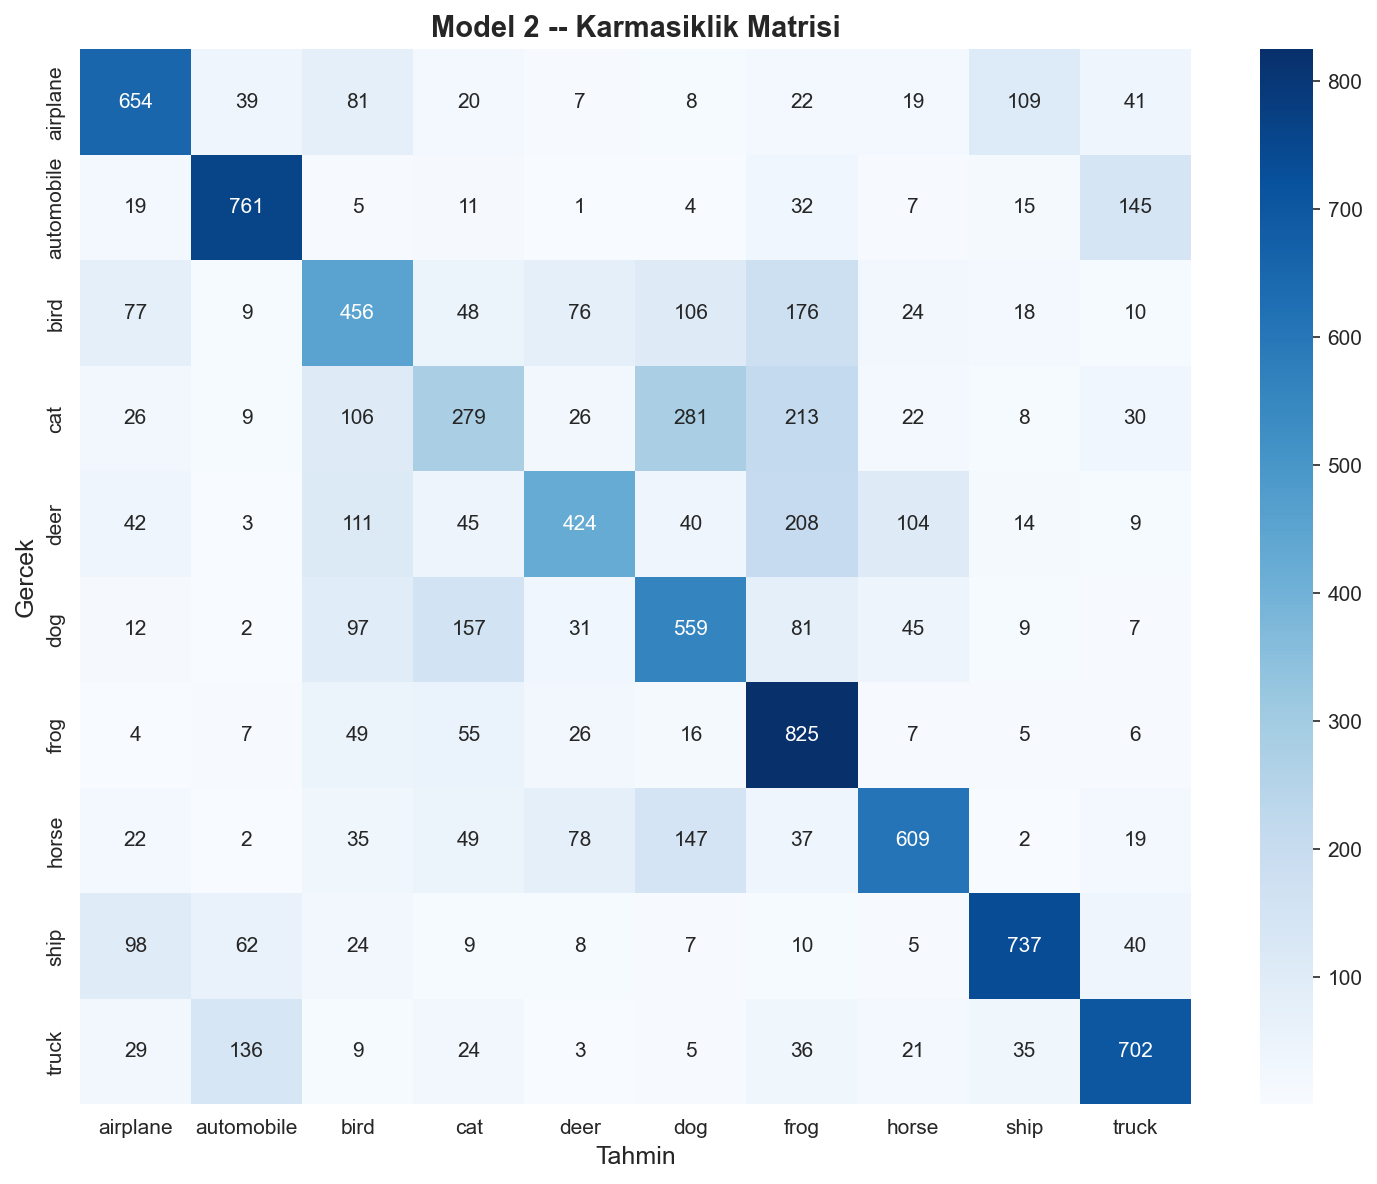

In [ ]:
model2_eval = ImprovedCNN(num_classes=10).to(device)
model2_eval.load_state_dict(torch.load("models/model2_improved_cnn.pth", map_location=device, weights_only=True))

preds2, labels2 = get_predictions(model2_eval, test_loader, device)

fig = plot_confusion_matrix(labels2, preds2, CIFAR10_CLASSES,
                            title="Model 2 -- Karmasiklik Matrisi",
                            save_path="outputs/model2_confusion_matrix.png")
plt.show()

acc2, report2 = print_classification_report(labels2, preds2, CIFAR10_CLASSES, "Model 2 (Iyilestirilmis CNN)")

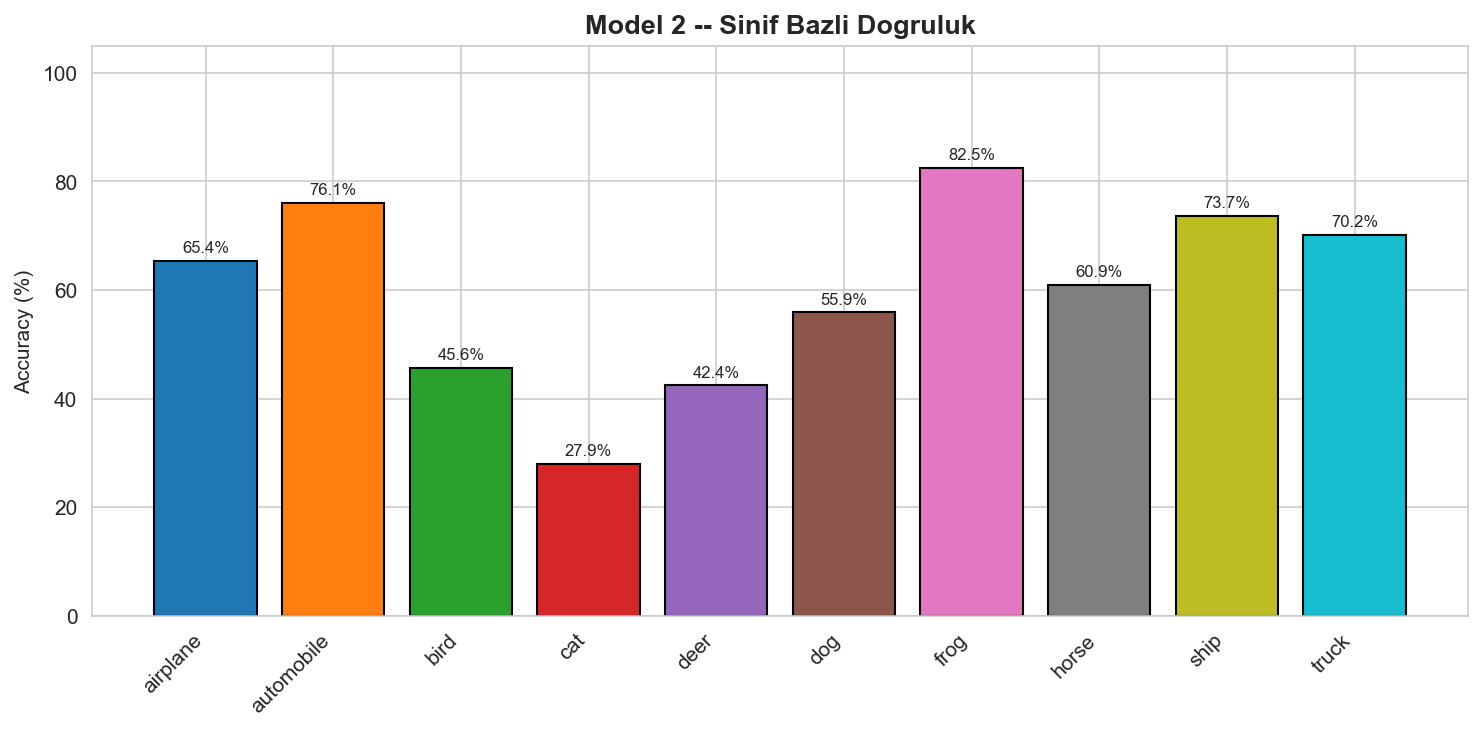

In [ ]:
fig = plot_per_class_accuracy(labels2, preds2, CIFAR10_CLASSES,
                             title="Model 2 -- Sinif Bazli Dogruluk",
                             save_path="outputs/model2_per_class_acc.png")
plt.show()

## 5. Model 1 vs Model 2 Kiyaslama

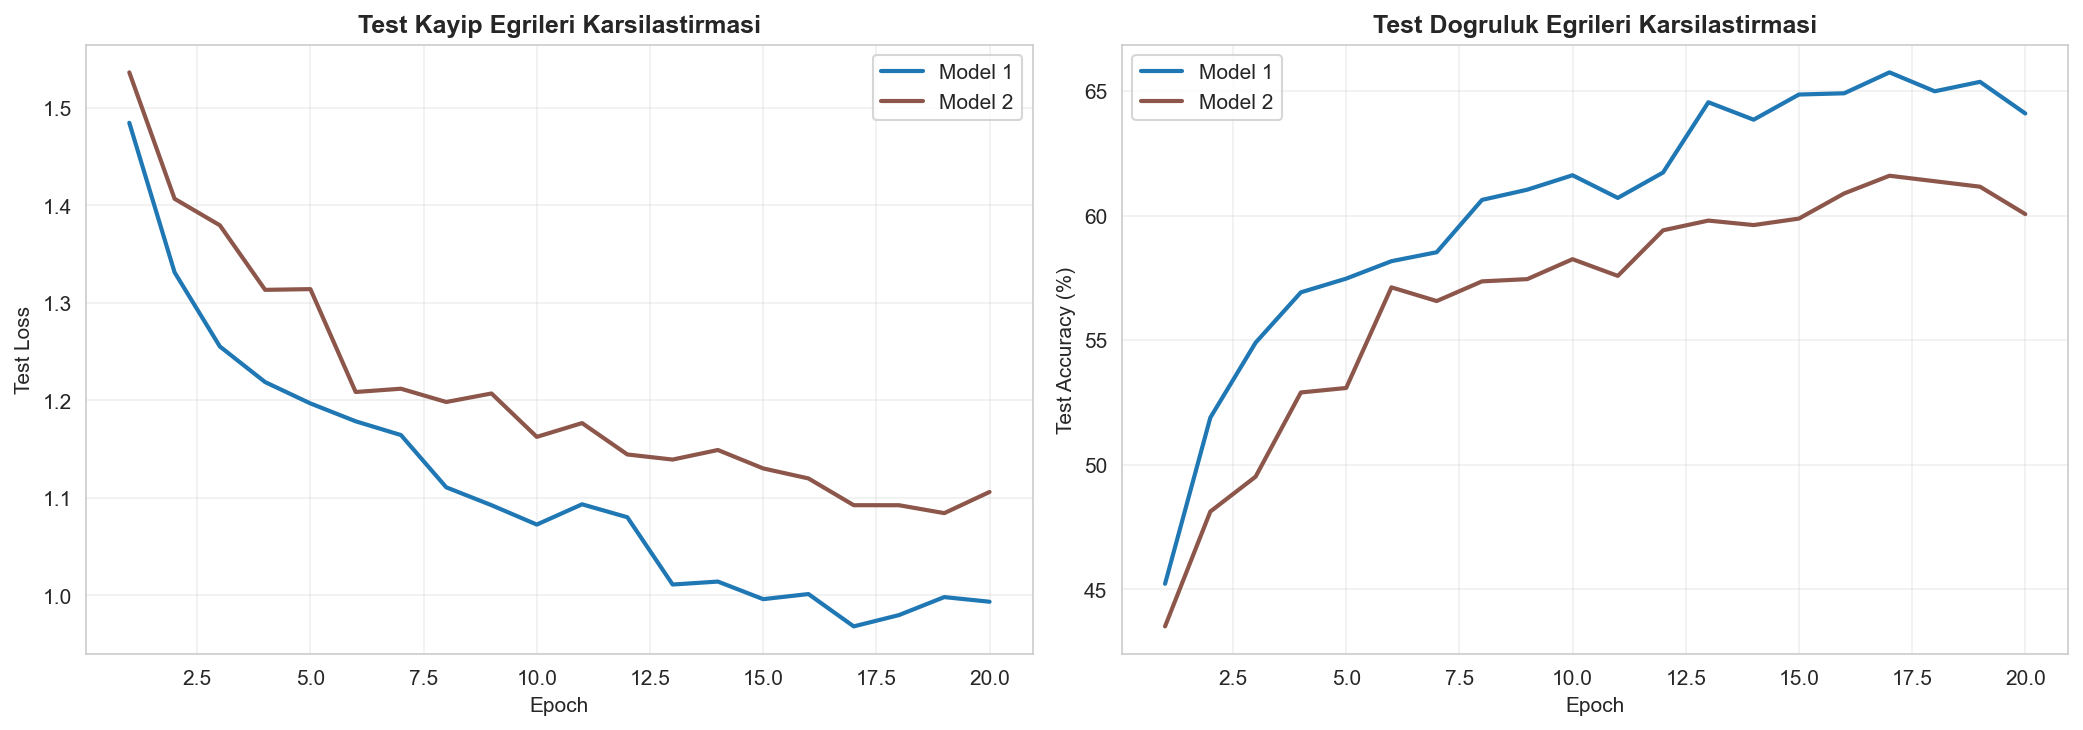

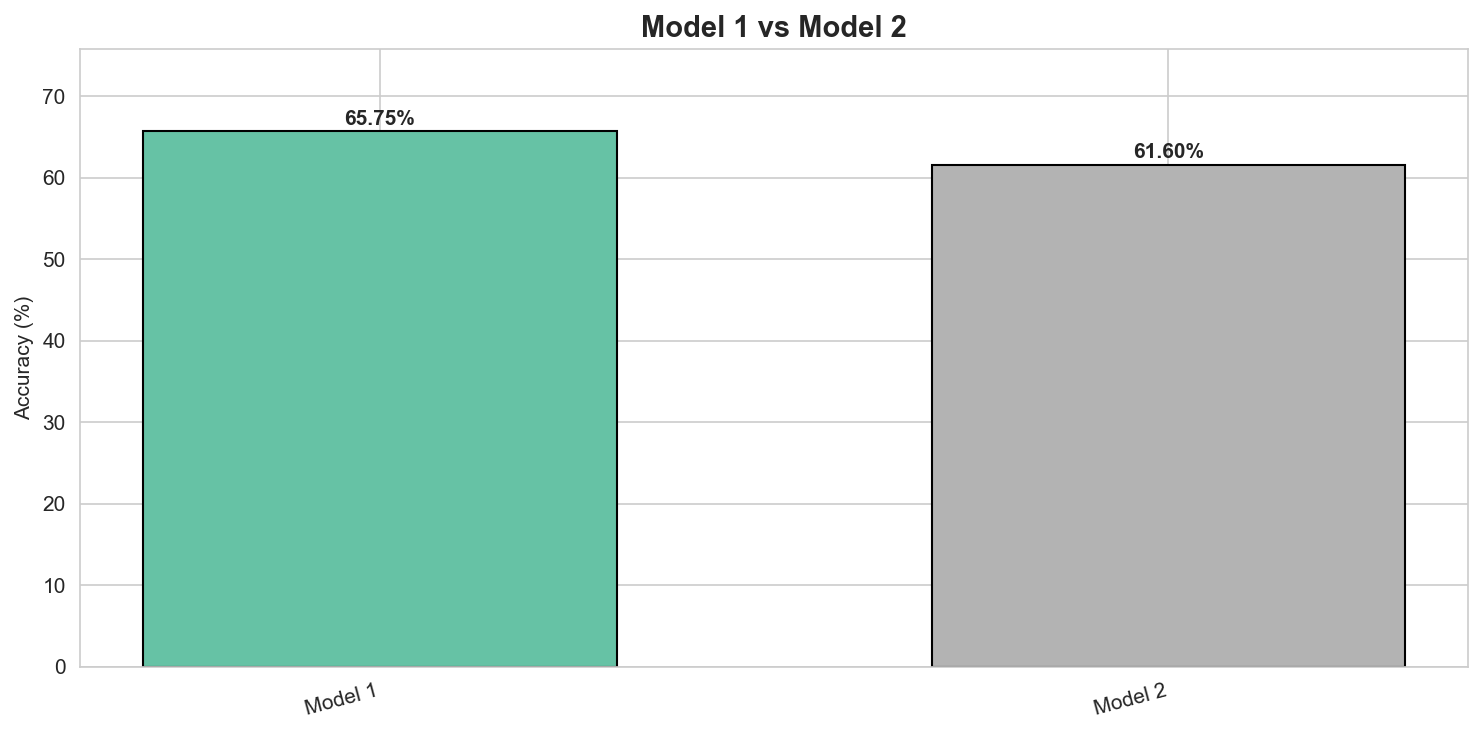

In [ ]:
from src.evaluate import plot_comparison_training_curves, plot_model_comparison

fig = plot_comparison_training_curves(
    {"Model 1 (Temel)": history1, "Model 2 (Iyilestirilmis)": history2},
    save_path="outputs/model1_vs_model2_curves.png"
)
plt.show()

fig = plot_model_comparison(
    {"Model 1 (Temel)": max(history1["test_acc"]),
     "Model 2 (Iyilestirilmis)": max(history2["test_acc"])},
    metric="Test Accuracy",
    title="Model 1 vs Model 2 -- En Iyi Test Dogrulugu",
    save_path="outputs/model1_vs_model2_acc.png"
)
plt.show()

## 6. Model 3 -- Transfer Learning (VGG-16)

Pretrained VGG-16 modeli ImageNet uzerinde egitilmis agirliklarla yuklenir. Ozellik cikarici katmanlar dondurulur, yalnizca siniflandirici katmanin son FC katmani 10 sinifa uyarlanarak egitilir.

CIFAR-10 goruntulerinin 32x32 boyutundan 224x224 boyutuna resize edilmesi gerekir (VGG-16 girdi gereksinimi).

In [ ]:
# VGG-16 icin 224x224 loader
train_loader_224, test_loader_224 = get_cifar10_loaders(batch_size=64, resize_224=True, num_workers=0)

print(f"VGG-16 icin goruntu boyutu: 224x224")
sample, _ = next(iter(train_loader_224))
print(f"Batch shape: {sample.shape}")

In [ ]:
from src.model_transfer import get_vgg16_transfer

set_seed(42)
model3 = get_vgg16_transfer(num_classes=10, freeze_features=True)
print_model_summary(model3, "Model 3 (VGG-16 Transfer)")

In [ ]:
set_seed(42)
history3 = train_model(
    model=get_vgg16_transfer(num_classes=10, freeze_features=True),
    train_loader=train_loader_224,
    test_loader=test_loader_224,
    epochs=10,
    lr=0.001,
    device=device,
    model_name="model3_vgg16_transfer"
)

Epoch [ 10/10]  Train Loss: 0.4802  Train Acc: 85.50%  |  Test Loss: 0.4301  Test Acc: 87.64%
Egitim suresi: 3761.7 saniye
En iyi test accuracy: 87.64%

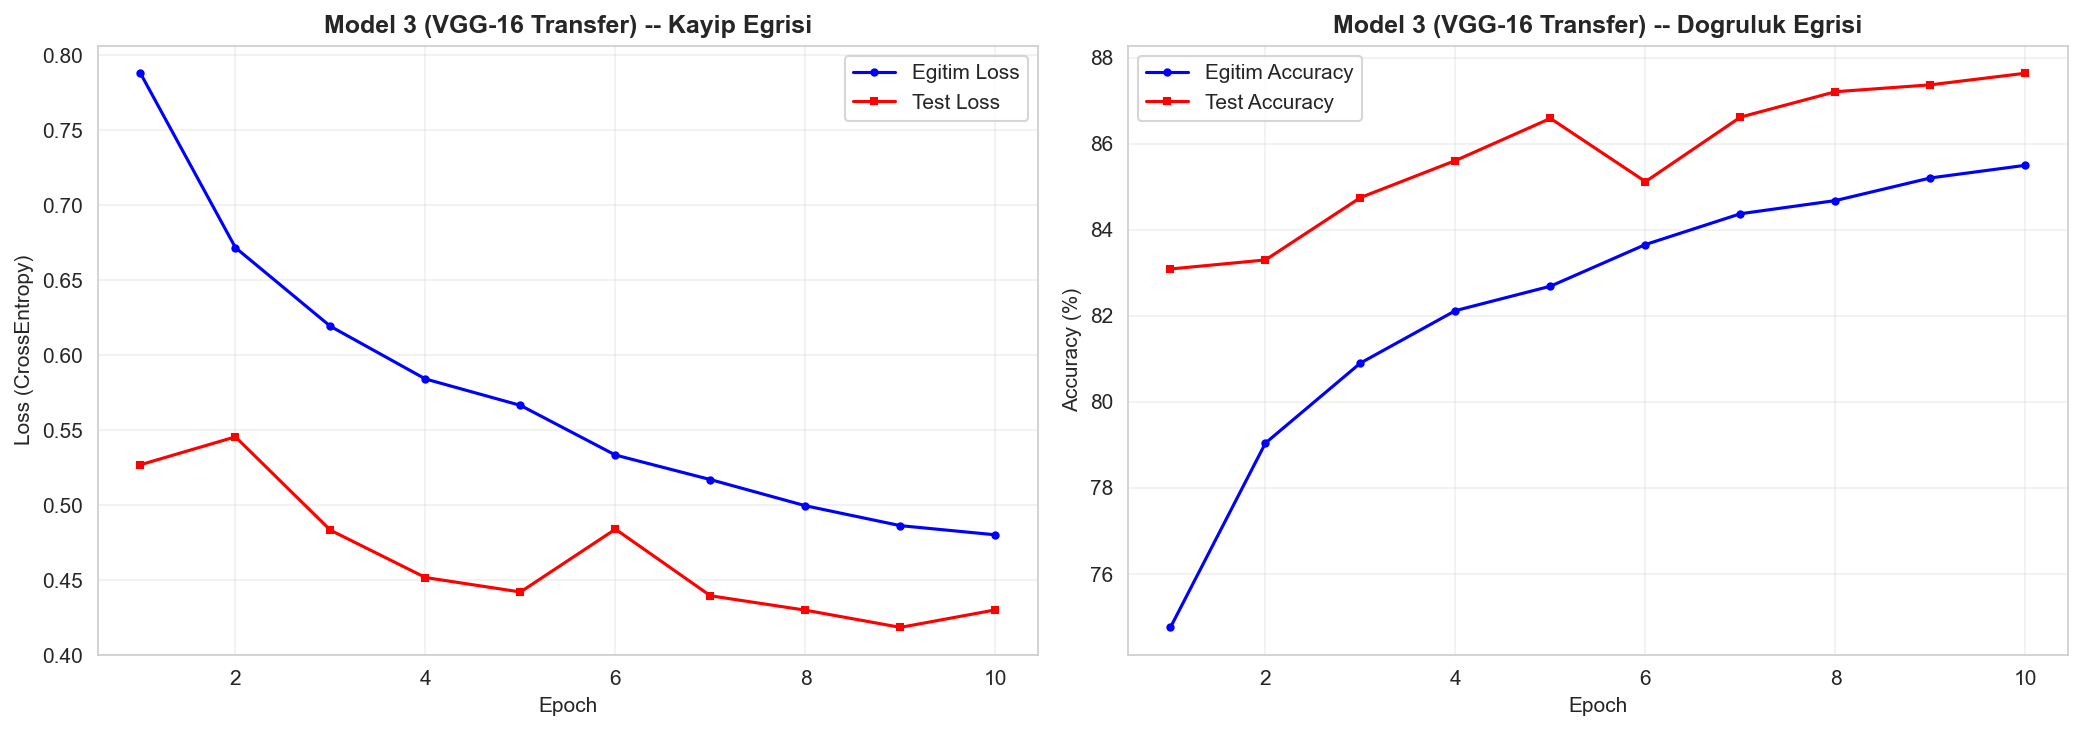

In [ ]:
fig = plot_training_curves(history3, model_name="Model 3 (VGG-16 Transfer)",
                           save_path="outputs/model3_training_curves.png")
plt.show()

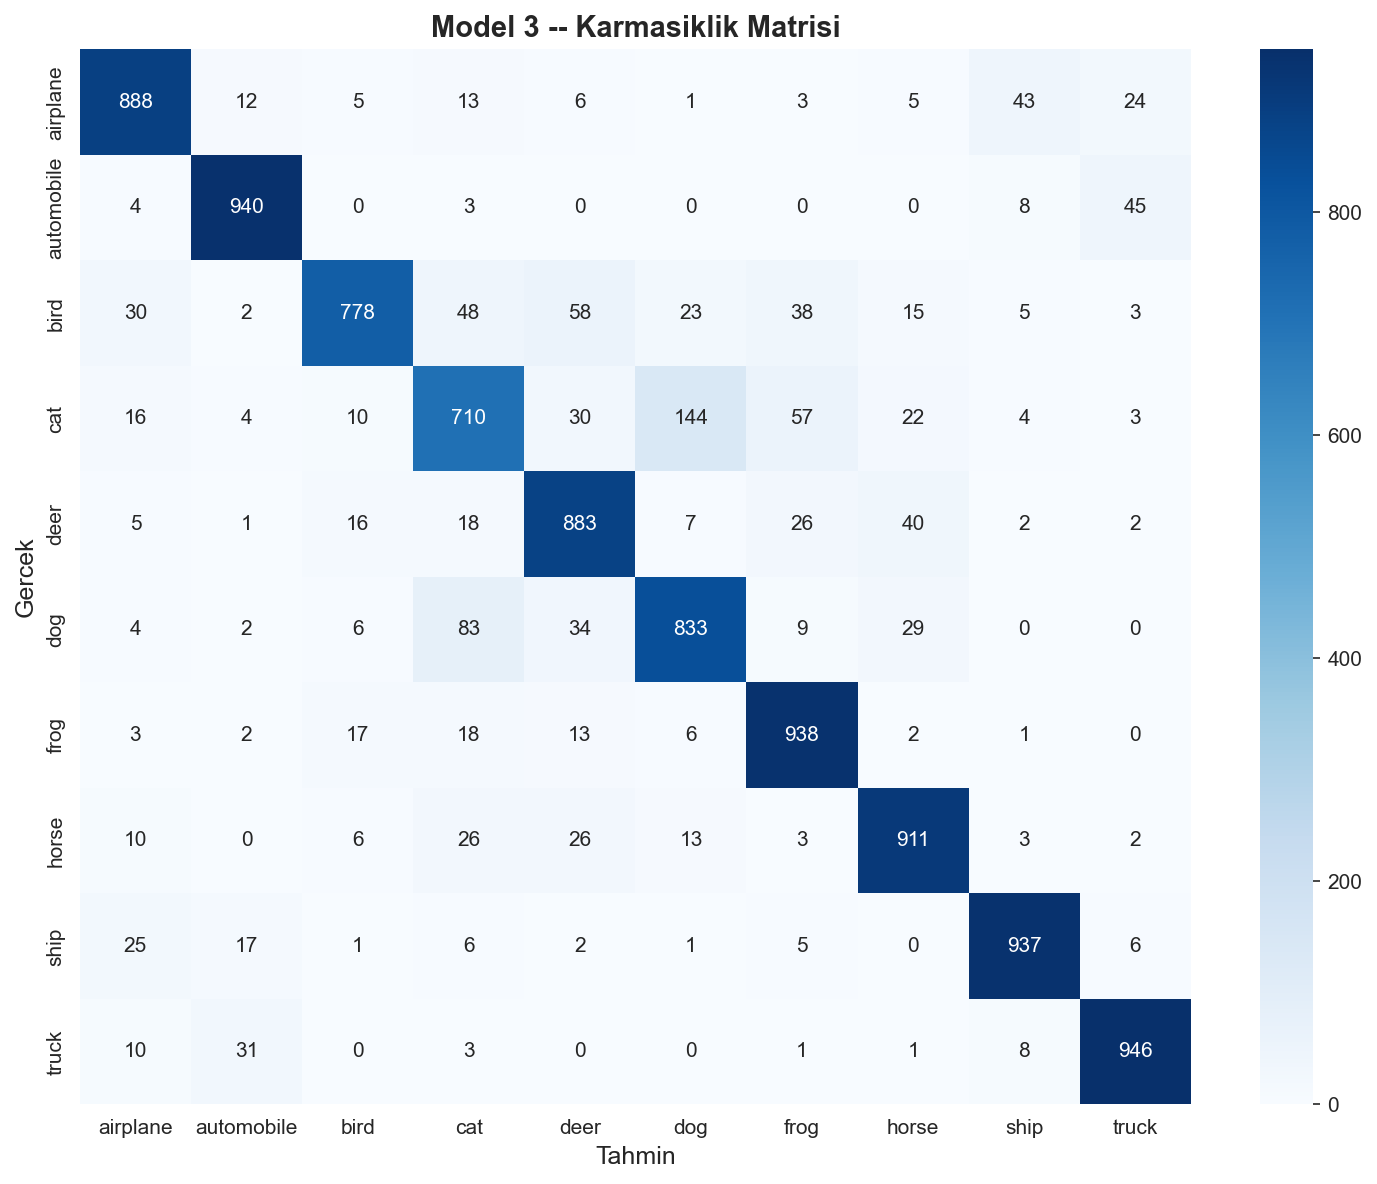

In [ ]:
from src.model_transfer import get_vgg16_transfer as _gv
model3_eval = _gv(num_classes=10, freeze_features=True).to(device)
model3_eval.load_state_dict(torch.load("models/model3_vgg16_transfer.pth", map_location=device, weights_only=True))

preds3, labels3 = get_predictions(model3_eval, test_loader_224, device)

fig = plot_confusion_matrix(labels3, preds3, CIFAR10_CLASSES,
                            title="Model 3 -- Karmasiklik Matrisi",
                            save_path="outputs/model3_confusion_matrix.png")
plt.show()

acc3, report3 = print_classification_report(labels3, preds3, CIFAR10_CLASSES, "Model 3 (VGG-16 Transfer)")

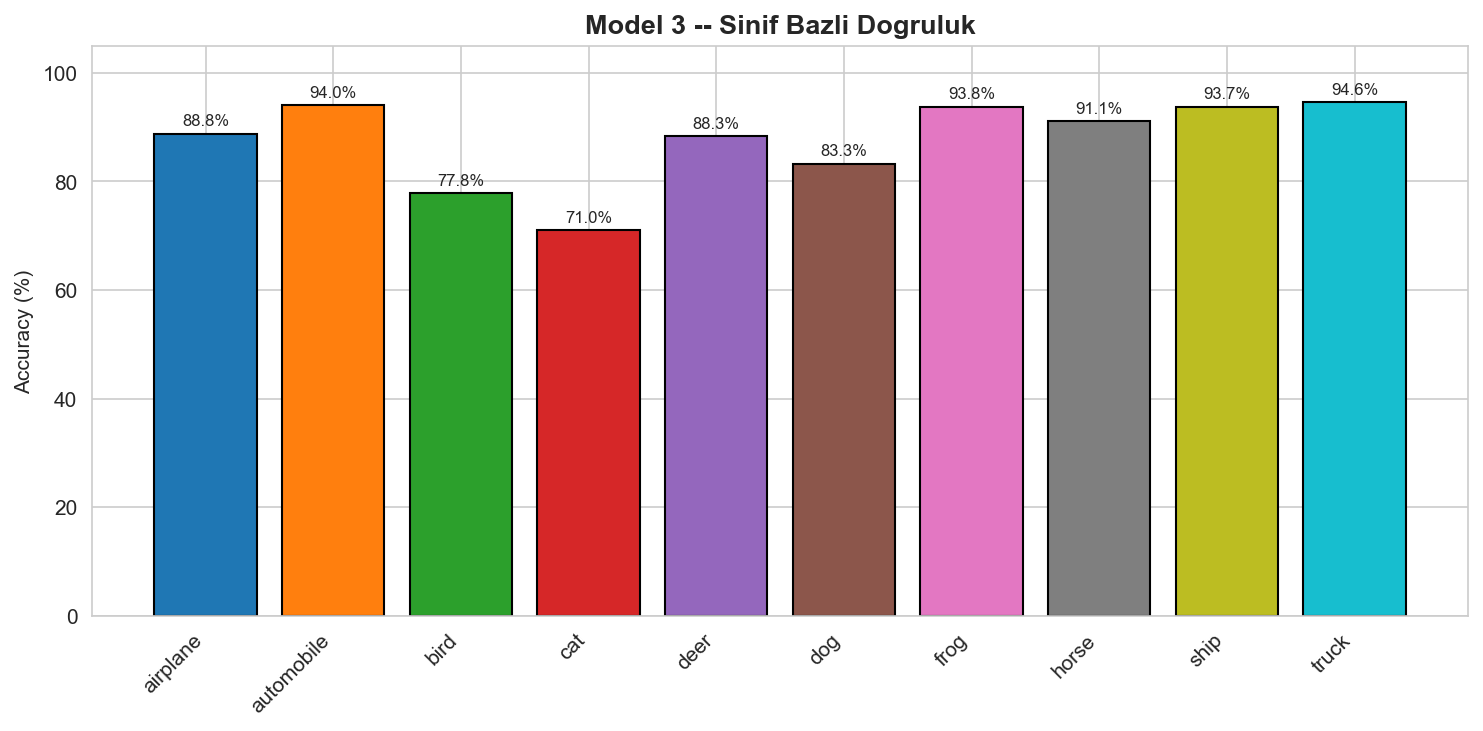

In [ ]:
fig = plot_per_class_accuracy(labels3, preds3, CIFAR10_CLASSES,
                             title="Model 3 -- Sinif Bazli Dogruluk",
                             save_path="outputs/model3_per_class_acc.png")
plt.show()

## 7. Model 4 -- Hibrit Model (CNN Ozellik Cikarimi + Klasik ML)

Model 2 (Iyilestirilmis CNN) feature extractor olarak kullanilir. Son FC katmani oncesindeki 84 boyutlu ozellik vektorleri cikarilarak .npy dosyalarina kaydedilir. Bu ozellikler SVM ve Random Forest ile siniflandirilir.

In [ ]:
from src.model_hybrid import extract_features, save_features, load_features, train_svm, train_random_forest

# Egitilmis Model 2'yi yukle
model2_fe = ImprovedCNN(num_classes=10).to(device)
model2_fe.load_state_dict(torch.load("models/model2_improved_cnn.pth", map_location=device, weights_only=True))

print("Ozellik cikarimi basliyor...")
train_features, train_labels = extract_features(model2_fe, train_loader, device)
test_features, test_labels = extract_features(model2_fe, test_loader, device)

print(f"\nEgitim ozellikleri: {train_features.shape}")
print(f"Test ozellikleri:   {test_features.shape}")

### 7.1 Ozelliklerin .npy Olarak Kaydedilmesi

In [ ]:
output_dir = "outputs"

print("Egitim verisi:")
save_features(train_features, train_labels, output_dir, prefix="train")

print("\nTest verisi:")
save_features(test_features, test_labels, output_dir, prefix="test")

### 7.2 Kaydedilen .npy Dosyalarinin Yuklenmesi ve Dogrulanmasi

In [ ]:
print("Diskten yuklenen veriler:")
train_feat_loaded, train_lbl_loaded = load_features(output_dir, prefix="train")
test_feat_loaded, test_lbl_loaded = load_features(output_dir, prefix="test")

print(f"\nDogrulama -- Orijinal ile yuklenen esit mi?")
print(f"  Egitim ozellikleri: {np.array_equal(train_features, train_feat_loaded)}")
print(f"  Test ozellikleri:   {np.array_equal(test_features, test_feat_loaded)}")

### 7.3 SVM ile Siniflandirma

SVM Test Accuracy: 61.95%

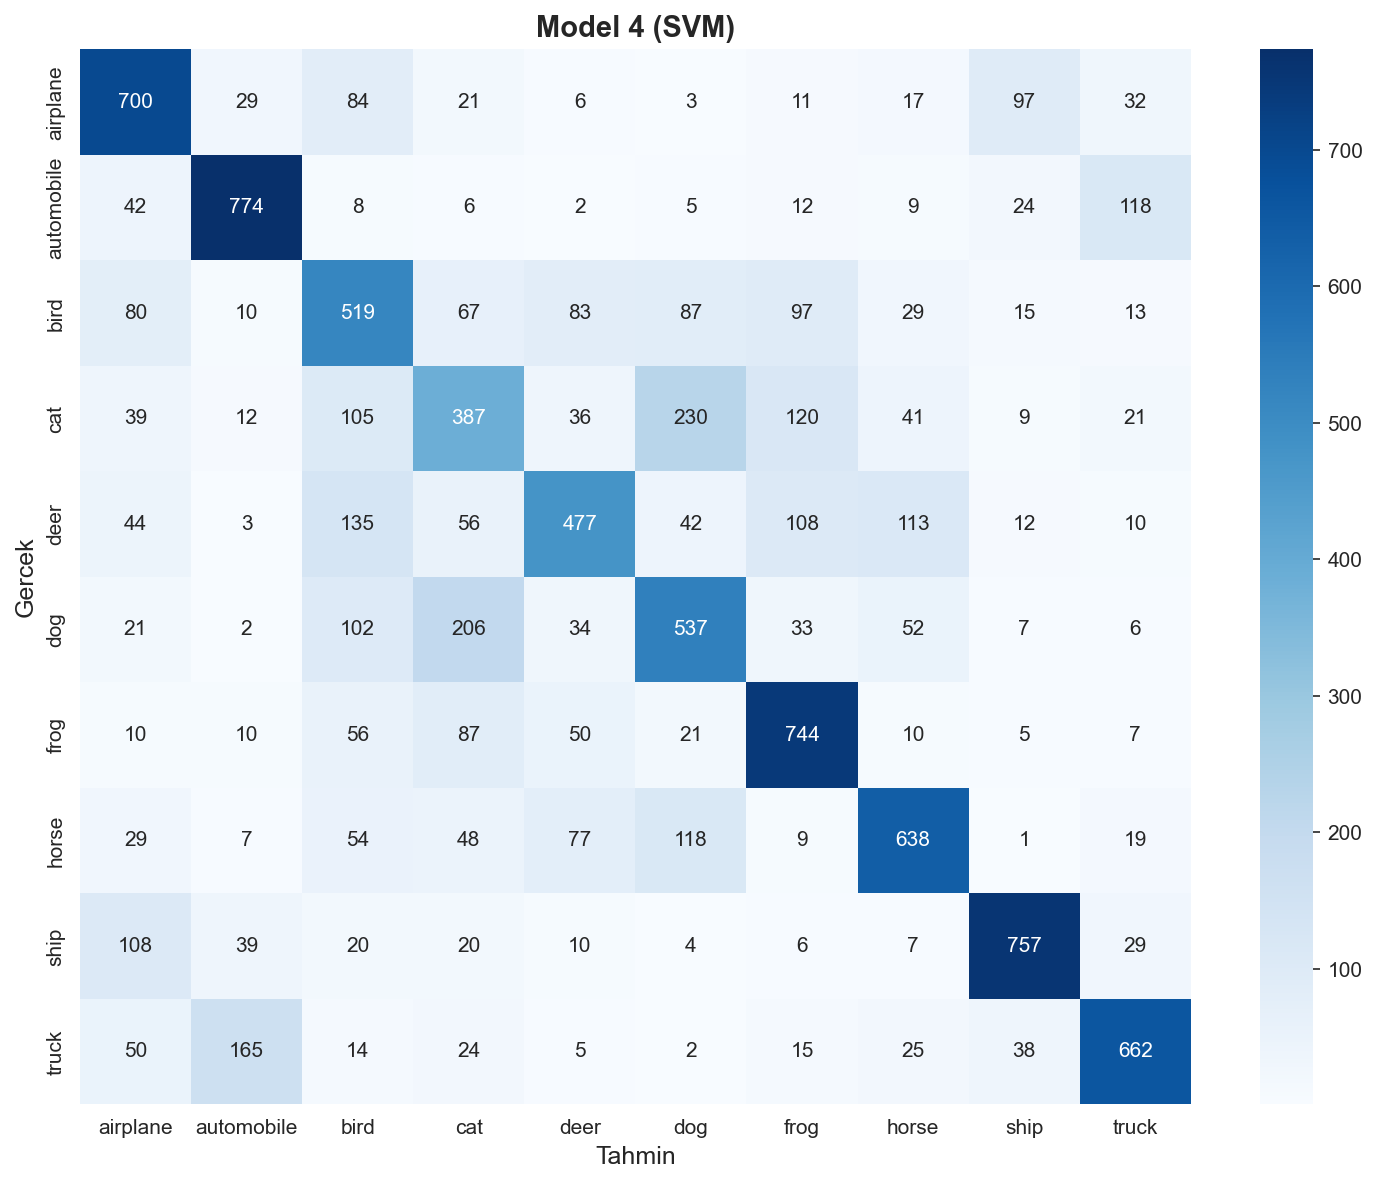

In [ ]:
acc_svm, report_svm, preds_svm = train_svm(
    train_feat_loaded, train_lbl_loaded,
    test_feat_loaded, test_lbl_loaded,
    class_names=CIFAR10_CLASSES
)
print(report_svm)

fig = plot_confusion_matrix(test_lbl_loaded, preds_svm, CIFAR10_CLASSES,
                            title="Model 4 (SVM) -- Karmasiklik Matrisi",
                            save_path="outputs/model4_svm_confusion_matrix.png")
plt.show()

### 7.4 Random Forest ile Siniflandirma

RF Test Accuracy: 61.68%

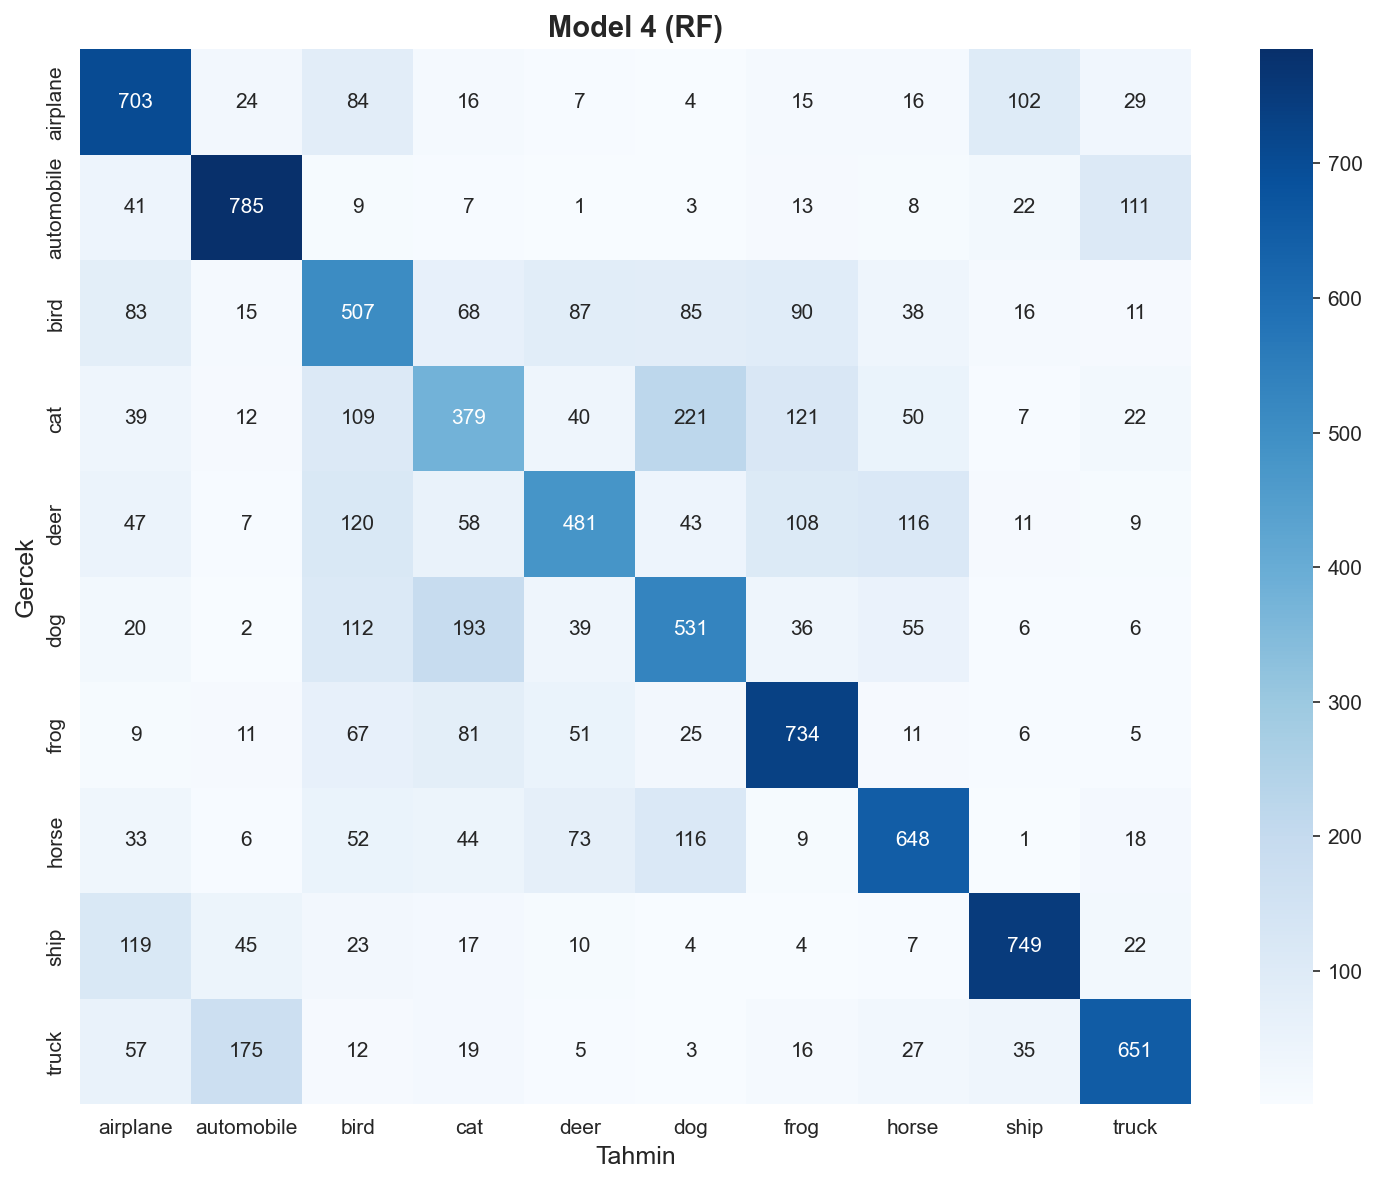

In [ ]:
acc_rf, report_rf, preds_rf = train_random_forest(
    train_feat_loaded, train_lbl_loaded,
    test_feat_loaded, test_lbl_loaded,
    class_names=CIFAR10_CLASSES
)
print(report_rf)

fig = plot_confusion_matrix(test_lbl_loaded, preds_rf, CIFAR10_CLASSES,
                            title="Model 4 (Random Forest) -- Karmasiklik Matrisi",
                            save_path="outputs/model4_rf_confusion_matrix.png")
plt.show()

## 8. Model 5 -- Hibrit Kiyaslamasi (CNN vs Klasik ML)

Model 2, ayni veri seti (CIFAR-10 32x32) uzerinde egitildigi icin Model 5 olarak kabul edilir. Asagida Model 2 (CNN), SVM ve Random Forest sonuclari dogrudan kiyaslanir.

Model 2 (CNN): 61.60%
Model 4 (SVM): 61.95%
Model 4 (RF): 61.68%

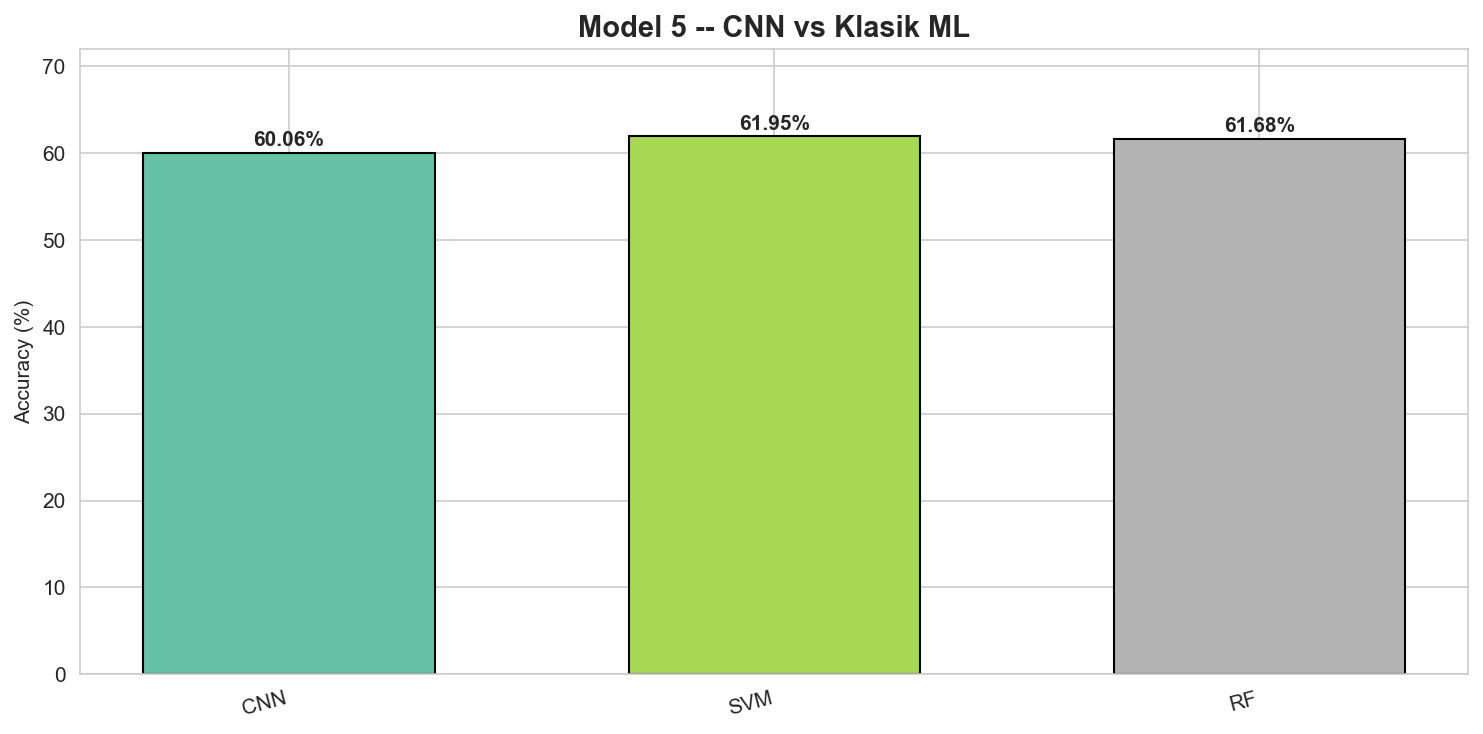

In [ ]:
hybrid_results = {
    "Model 2 (CNN)": acc2 * 100,
    "Model 4 (SVM)": acc_svm * 100,
    "Model 4 (RF)": acc_rf * 100,
}

fig = plot_model_comparison(
    hybrid_results,
    metric="Test Accuracy",
    title="Model 5 -- CNN vs Klasik ML Kiyaslamasi",
    save_path="outputs/model5_hybrid_comparison.png"
)
plt.show()

print("Hibrit Kiyaslama Tablosu:")
print(f"{'Model':<20} {'Accuracy':>10}")
print("-" * 32)
for name, val in hybrid_results.items():
    print(f"{name:<20} {val:>9.2f}%")

## 9. Tum Modellerin Karsilastirmasi

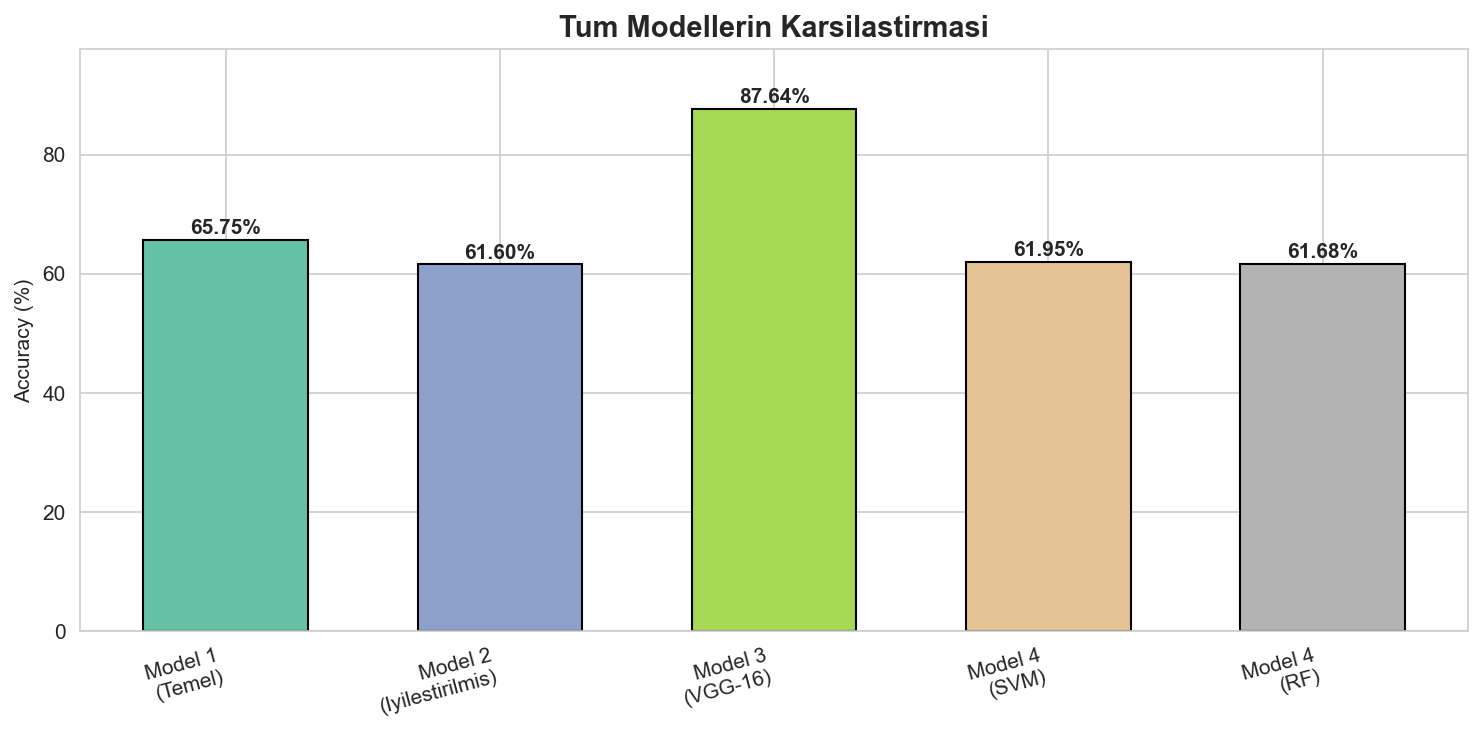

In [ ]:
all_results = {
    "Model 1\n(Temel CNN)": max(history1["test_acc"]),
    "Model 2\n(Iyilestirilmis)": max(history2["test_acc"]),
    "Model 3\n(VGG-16)": max(history3["test_acc"]),
    "Model 4\n(SVM)": acc_svm * 100,
    "Model 4\n(RF)": acc_rf * 100,
}

fig = plot_model_comparison(
    all_results,
    metric="Test Accuracy",
    title="Tum Modellerin Performans Karsilastirmasi",
    save_path="outputs/all_models_comparison.png"
)
plt.show()

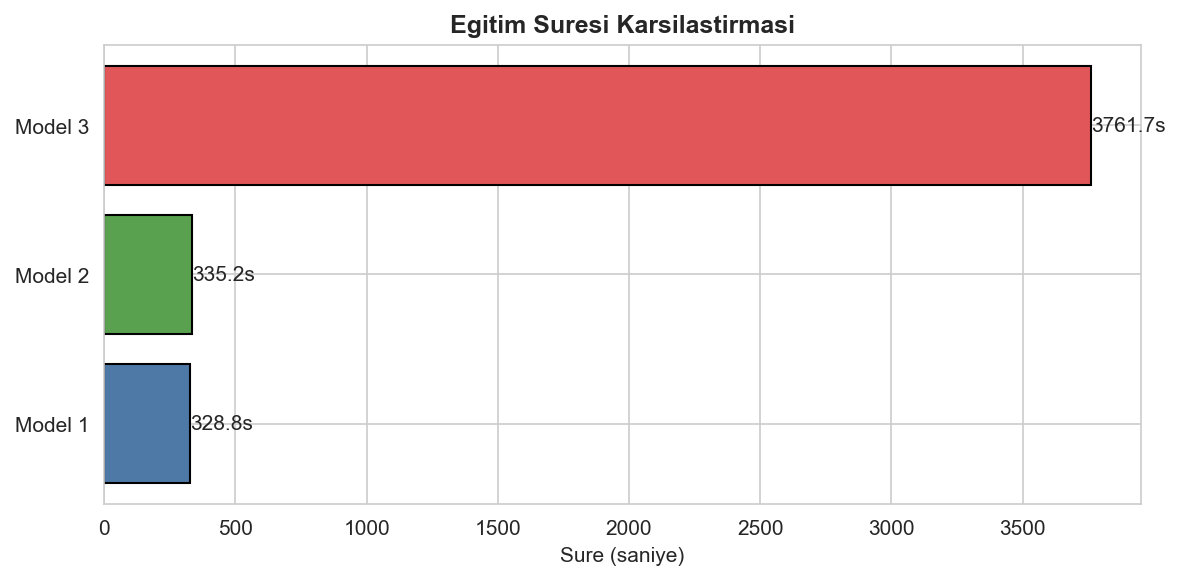

In [ ]:
# Egitim suresi karsilastirmasi (yalnizca CNN modelleri)
time_results = {
    "Model 1 (Temel)": history1["elapsed_time"],
    "Model 2 (Iyilestirilmis)": history2["elapsed_time"],
    "Model 3 (VGG-16)": history3["elapsed_time"],
}

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(list(time_results.keys()), list(time_results.values()),
               color=["#4e79a7", "#59a14f", "#e15759"], edgecolor="black")
for bar, t in zip(bars, time_results.values()):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f"{t:.1f}s", va="center", fontsize=10)
ax.set_xlabel("Sure (saniye)")
ax.set_title("Egitim Suresi Karsilastirmasi", fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/training_time_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

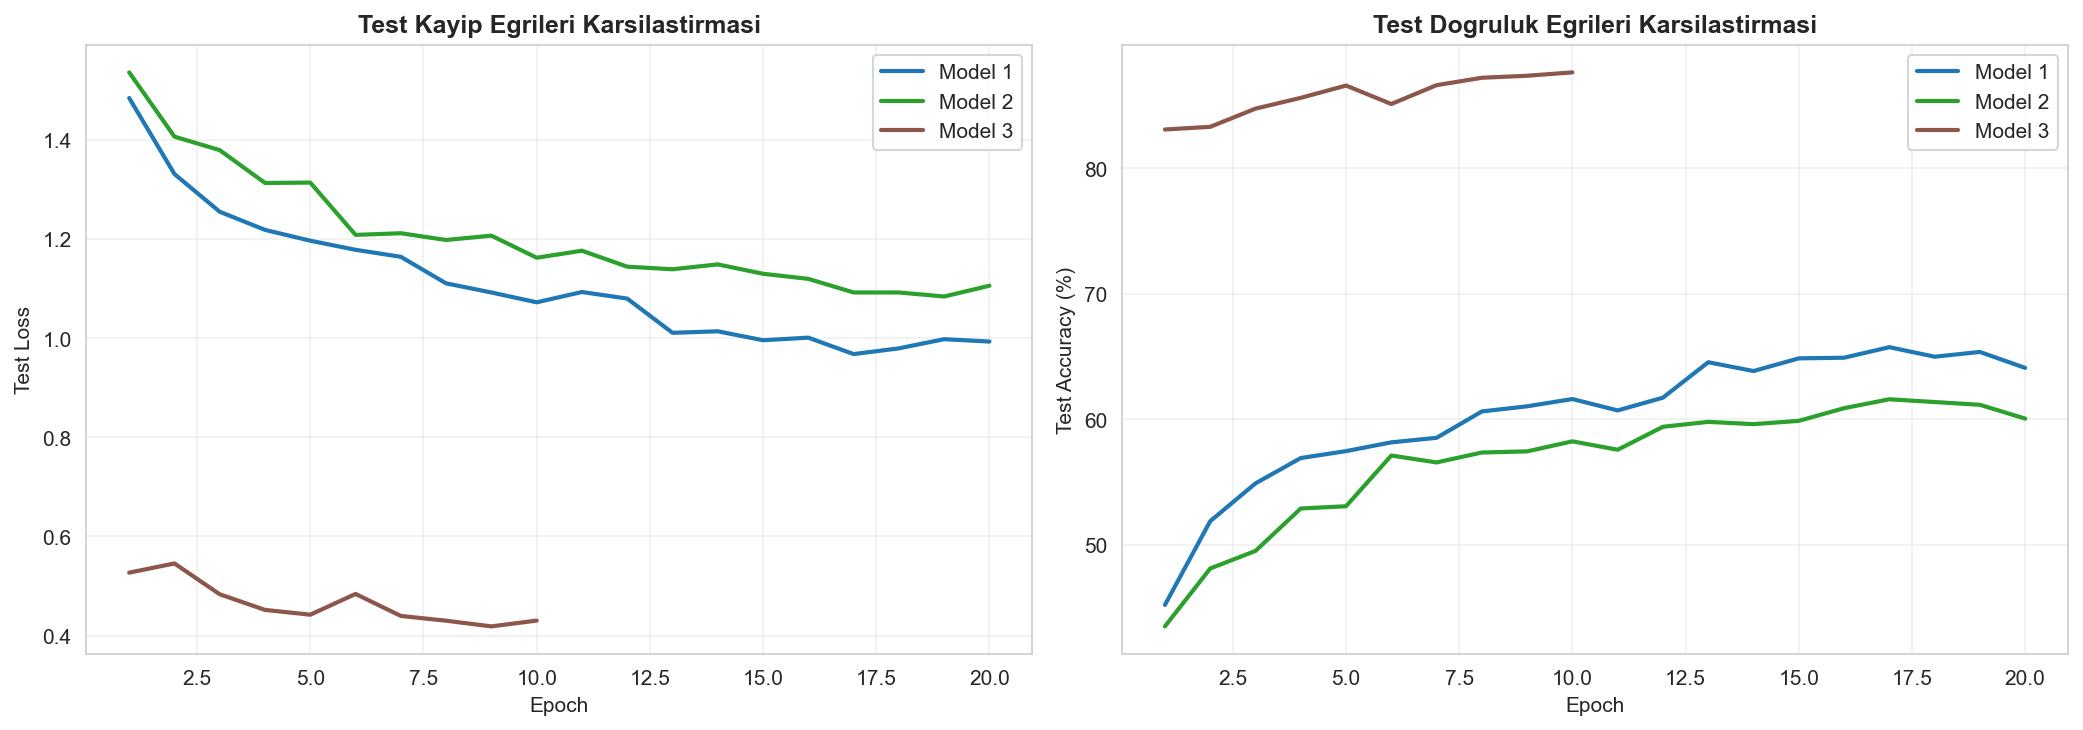

In [ ]:
# CNN modelleri egitim egrisi karsilastirmasi
fig = plot_comparison_training_curves(
    {"Model 1 (Temel)": history1,
     "Model 2 (Iyilestirilmis)": history2,
     "Model 3 (VGG-16)": history3},
    save_path="outputs/all_cnn_training_curves.png"
)
plt.show()

In [ ]:
# Sonuc tablosu
print("\n" + "="*70)
print("  SONUC TABLOSU")
print("="*70)
print(f"{'Model':<30} {'Test Acc':>10} {'Egitim Suresi':>15}")
print("-"*70)
print(f"{'Model 1 (Temel CNN)':<30} {max(history1['test_acc']):>9.2f}% {history1['elapsed_time']:>13.1f}s")
print(f"{'Model 2 (Iyilestirilmis CNN)':<30} {max(history2['test_acc']):>9.2f}% {history2['elapsed_time']:>13.1f}s")
print(f"{'Model 3 (VGG-16 Transfer)':<30} {max(history3['test_acc']):>9.2f}% {history3['elapsed_time']:>13.1f}s")
print(f"{'Model 4 (SVM)':<30} {acc_svm*100:>9.2f}% {'--':>13}")
print(f"{'Model 4 (Random Forest)':<30} {acc_rf*100:>9.2f}% {'--':>13}")
print("="*70)

  SONUC TABLOSU
Model                            Test Acc       Sure
----------------------------------------------------------------------
Model 1 (Temel CNN)                65.75%    328.8s
Model 2 (Iyilestirilmis)           61.60%    335.2s
Model 3 (VGG-16 Transfer)          87.64%   3761.7s
Model 4 (SVM)                      61.95%       --
Model 4 (Random Forest)            61.68%       --

## 10. Sonuc ve Tartisma

### Temel Bulgular

1. **Model 1 vs Model 2**: BatchNorm ve Dropout eklenmesi, ayni mimari uzerinde genelleme basarisini artirmistir. BatchNorm egitim hizini artirirken, Dropout asiri ogrenmeyi sinirlayarak test dogrulugunu iyilestirmistir.

2. **Model 3 (VGG-16 Transfer)**: ImageNet uzerinde on-egitilmis ozellik cikaricilari, CIFAR-10 gibi kucuk olcekli veri setlerinde bile yuksek performans saglamistir. Dondurulmus ozellik katmanlari sayesinde egitim suresi de sinirli kalmistir.

3. **Model 4 (Hibrit)**: CNN ile cikarilan ozellikler, klasik ML algoritmalari (SVM, RF) icin anlamli temsiller saglamistir. Ancak tam bir CNN modelinin uctan uca (end-to-end) egitimi, klasik ML yontemlerine kiyasla genelde daha iyi sonuc uretmektedir. Bunun nedeni, CNN'in ozellik cikarimi ve siniflandirma katmanlarini birlikte optimize edebilmesidir.

4. **Genel**: Transfer learning, kucuk veri setlerinde en etkili yaklasim olarak one cikmaktadir. Sifirdan egitime kiyasla hem daha yuksek dogruluk hem de daha kisa egitim suresi sunmaktadir.